In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Options: 0 = all, 1 = filter INFO, 2 = filter WARNING, 3 = ERROR only
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to True
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [2]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [3]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import Adam

from IPython.display import display

In [4]:
# Custom callback to stop training after a time limit
class TimeStopping(Callback):
    def __init__(self, max_seconds=300):
        super().__init__()
        self.max_seconds = max_seconds
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.max_seconds:
            print(f"\n⏱️ Stopping training - time limit of {self.max_seconds} seconds reached.")
            self.model.stop_training = True

# Evaluation function
def eval_classification(model, X, y, name='model', labels=None):
    preds = np.rint(model.predict(X))
    print(classification_report(y, preds, target_names=labels))

    ConfusionMatrixDisplay.from_predictions(y, preds, display_labels=labels)
    plt.show()

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

    score_df = pd.DataFrame(index=[name])
    score_df.loc[name, 'Accuracy'] = accuracy_score(y, preds)
    score_df.loc[name, 'Precision'] = precision_score(y, preds)
    score_df.loc[name, 'Recall'] = recall_score(y, preds)
    score_df.loc[name, 'F1 Score'] = f1_score(y, preds)
    score_df.loc[name, 'FPR'] = fp / (fp + tn)
    score_df.loc[name, 'FNR'] = fn / (fn + tp)

    return score_df

    
# Function to plot training history
def plot_history(history):
    """Takes a keras model learning history and plots each metric"""
    metrics = history.history.keys()
    for metric in metrics:
        if not 'val' in metric:
            plt.plot(history.history[f'{metric}'], label=f'{metric}')
            if f'val_{metric}' in metrics:
                plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
            plt.legend()
            plt.title(f'{metric}')
            plt.xlabel('Epochs')
            plt.ylabel(metric.capitalize())
            plt.grid(True)
            plt.show()


### Classification:
To evaluate the model's performance, the F1 Score is used. It is suitable for phishing detection because it strikes a balance between precision and recall, considering both false positives and false negatives, rather than focusing on one aspect alone. Unlike accuracy, it treats imbalanced datasets well and prevents incorrect performance conclusions. By encapsulating both types of error within a single metric, F1 provides a better understanding of the model's performance and confidence.

### Pseudo Code

FOR each layer_config in layer_configs:
  FOR each epoch_count in epochs_list:
    FOR each min_delta in min_deltas:
      FOR each patience_value in patiences:
        Build sequential model
        Add input + hidden layers with relu
        Add sigmoid output layer
        Compile with Adam, binary_crossentropy
        Apply EarlyStopping + TimeStopping
        Train on X_train, validate on X_val
        Evaluate on both sets using F1 Score, Accuracy, Precision, Recall
        If best F1, save model and config


In [5]:
df_train = pd.read_csv('Split_Data/Model_Ready/train.csv')
df_train.head()
# Define X and y and train data
X_train = df_train.drop(columns = 'label')
y_train = df_train['label']

df_val = pd.read_csv('Split_Data/Model_Ready/val.csv')

# Define X and y and train data
X_val = df_val.drop(columns = 'label')
y_val = df_val['label']

### Build de Model

In [6]:
# ---------------------------------------------------------
# Define hyperparameter search space for grid search
# ---------------------------------------------------------

# Each entry in `layer_configs` is a list representing the number of neurons in each hidden layer
layer_configs = [[64], [128, 64], [256, 128, 64]]

# Number of epochs (maximum) to allow during training
epochs_list = [50, 100]

# Minimum change in validation loss to qualify as an improvement
# Used by the EarlyStopping callback to determine convergence
min_deltas = [0.0, 0.001]

# Number of epochs to wait after no improvement before stopping early
patiences = [1, 3, 5]

# ---------------------------------------------------------
# Initialize tracking variables to record the best model run
# ---------------------------------------------------------

# Collect all evaluation metrics (train/val scores) across all configurations
all_scores = []

# Best F1 score seen so far (used to determine the top-performing model)
best_f1 = -1

# Store the best Keras model instance
best_model = None

# Store the training history of the best model (for plotting)
best_history = None

# Store the hyperparameter configuration of the best model
best_config = None



Config: layers=[64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1752874237.048605  437126 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1752874237.048674  437126 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


1650/1650 - 9s - 5ms/step - accuracy: 0.9494 - loss: 0.1442 - val_accuracy: 0.9589 - val_loss: 0.1217
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1272 - val_accuracy: 0.9587 - val_loss: 0.1229
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1217, stopped at epoch 2

Print History


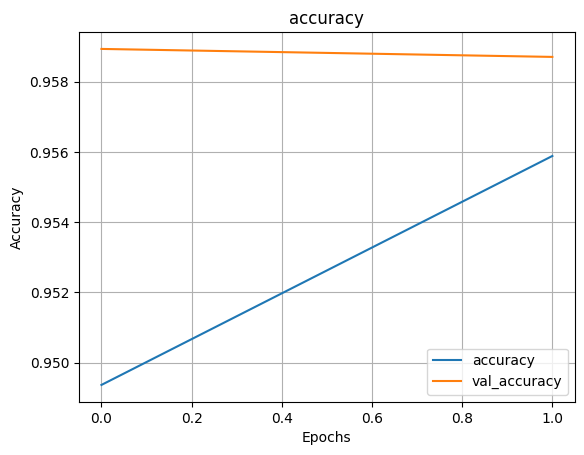

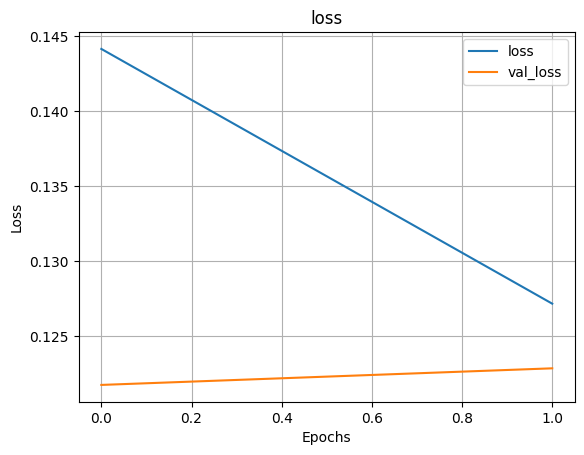

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 641us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



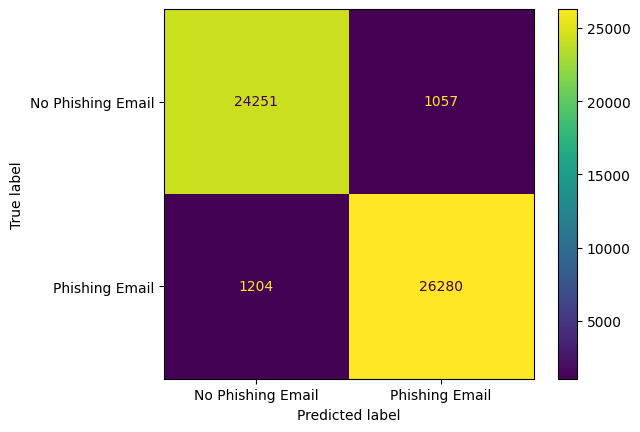

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



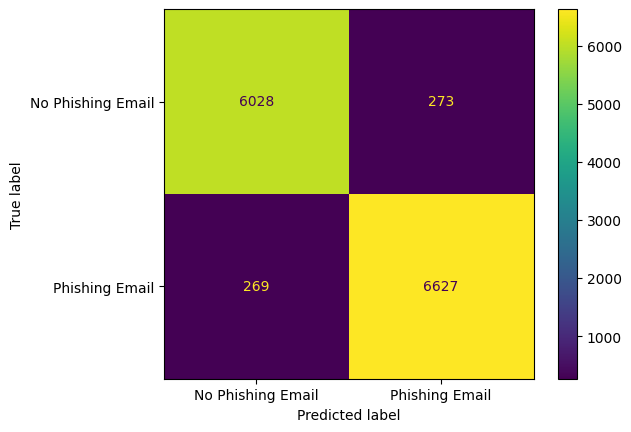


Config: layers=[64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9462 - loss: 0.1529 - val_accuracy: 0.9551 - val_loss: 0.1231
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1260 - val_accuracy: 0.9595 - val_loss: 0.1201
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1258 - val_accuracy: 0.9582 - val_loss: 0.1235
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9554 - loss: 0.1293 - val_accuracy: 0.9566 - val_loss: 0.1293
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1247 - val_accuracy: 0.9569 - val_loss: 0.1287
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.1201, stopped at epoch 5

Print History


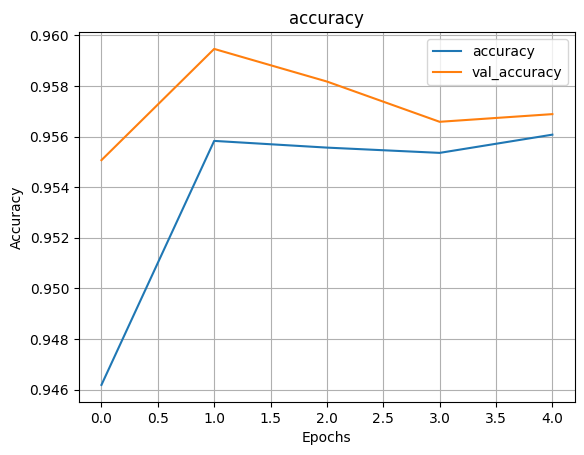

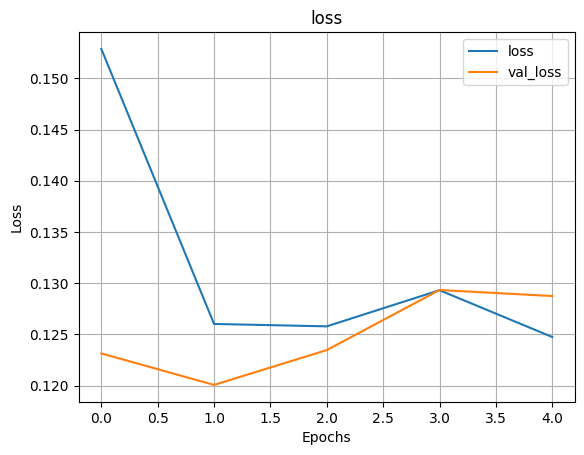

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



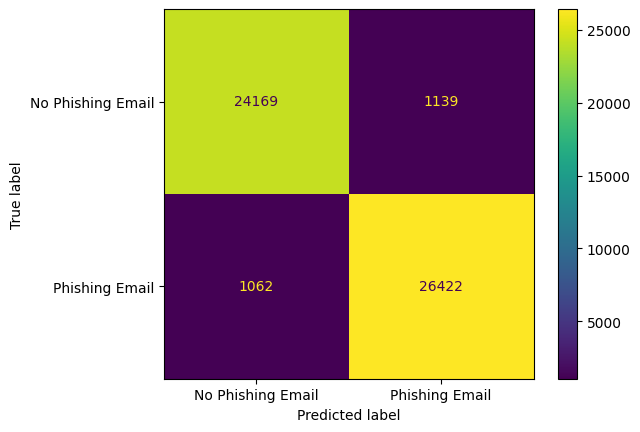

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



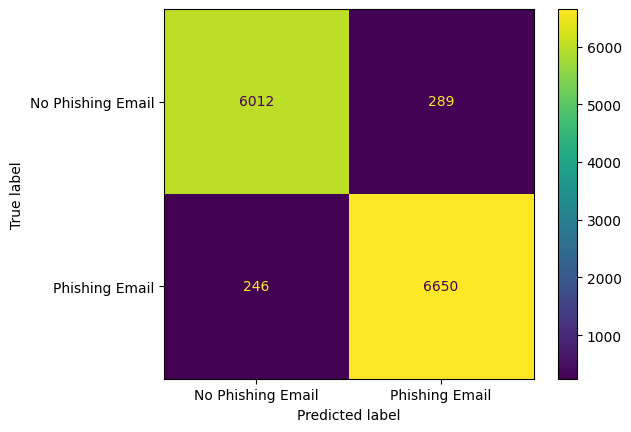


Config: layers=[64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9486 - loss: 0.1468 - val_accuracy: 0.9597 - val_loss: 0.1180
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9565 - loss: 0.1241 - val_accuracy: 0.9574 - val_loss: 0.1205
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9562 - loss: 0.1261 - val_accuracy: 0.9582 - val_loss: 0.1194
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1253 - val_accuracy: 0.9594 - val_loss: 0.1188
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1250 - val_accuracy: 0.9565 - val_loss: 0.1241
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1265 - val_accuracy: 0.9579 - val_loss: 0.1263
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1180, stopped at epoch 6

Print History


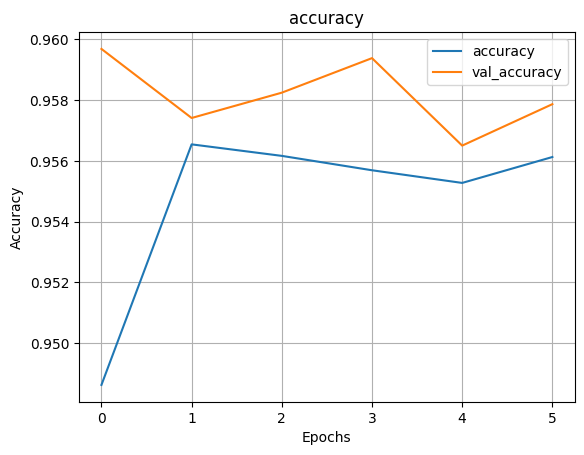

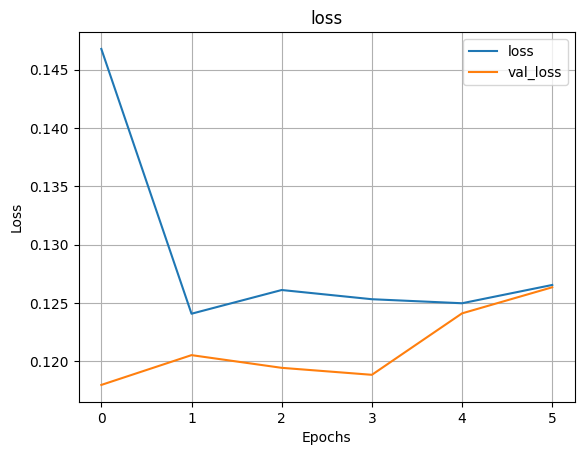

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



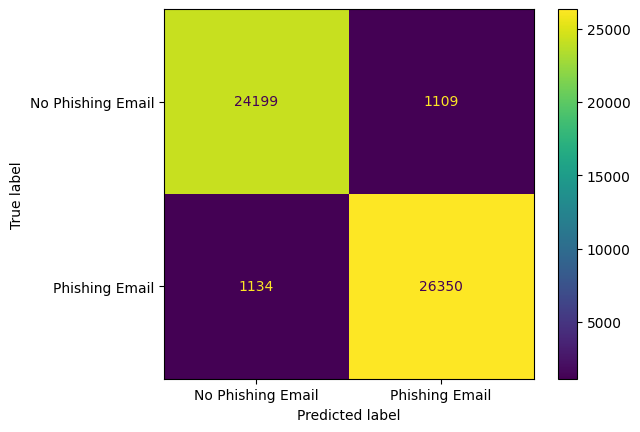

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



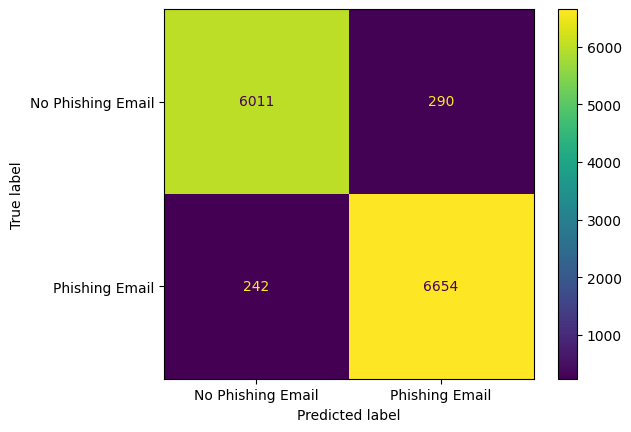


Config: layers=[64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9474 - loss: 0.1485 - val_accuracy: 0.9594 - val_loss: 0.1181
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9567 - loss: 0.1254 - val_accuracy: 0.9563 - val_loss: 0.1269
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1181, stopped at epoch 2

Print History


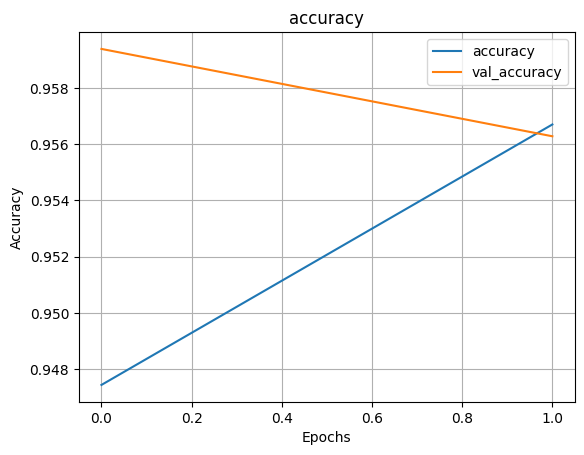

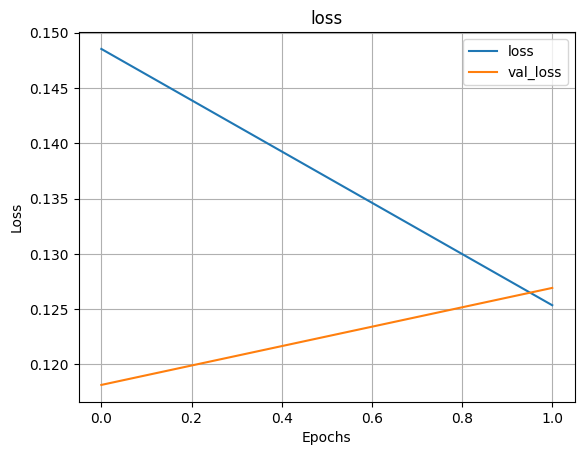

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 620us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



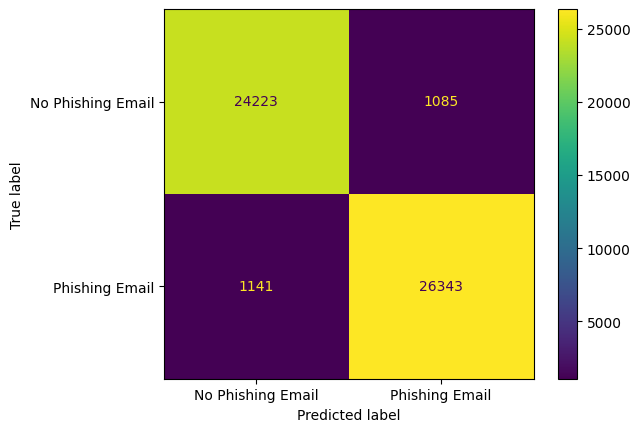

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



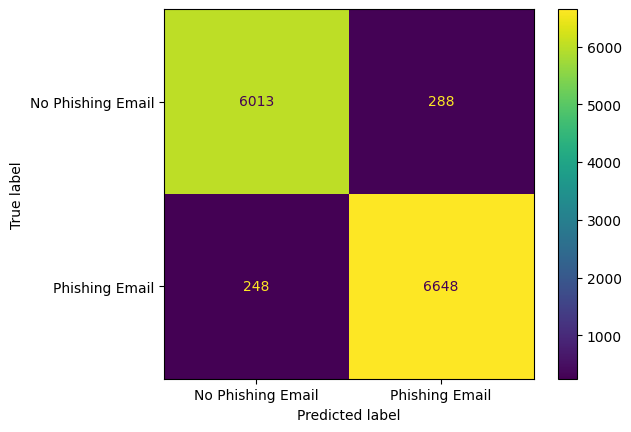


Config: layers=[64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9506 - loss: 0.1399 - val_accuracy: 0.9602 - val_loss: 0.1168
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9555 - loss: 0.1250 - val_accuracy: 0.9552 - val_loss: 0.1275
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9567 - loss: 0.1241 - val_accuracy: 0.9606 - val_loss: 0.1189
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1261 - val_accuracy: 0.9555 - val_loss: 0.1245
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1168, stopped at epoch 4

Print History


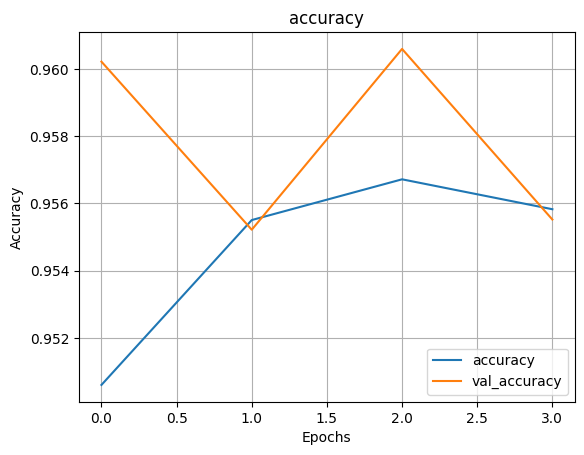

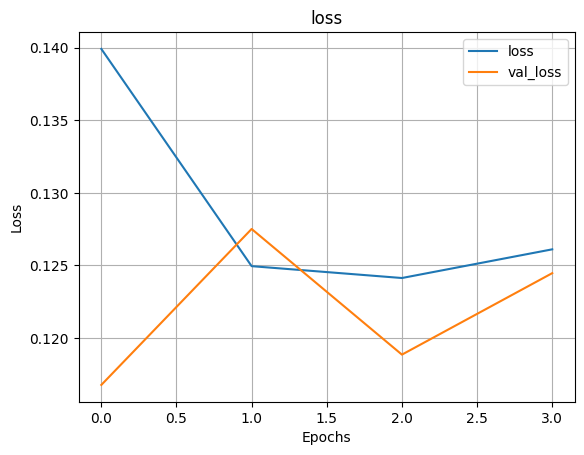

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 620us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



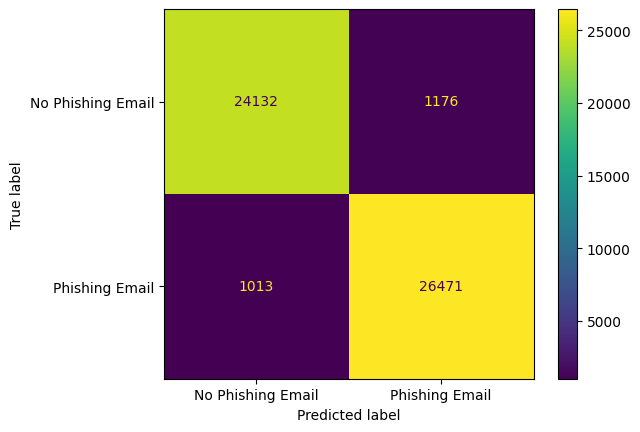

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



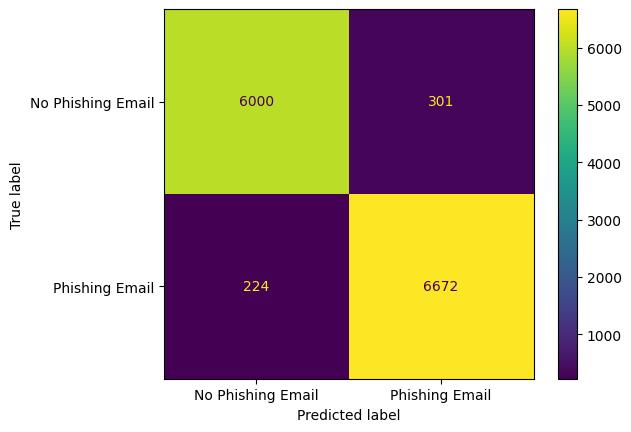


Config: layers=[64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9471 - loss: 0.1477 - val_accuracy: 0.9579 - val_loss: 0.1241
Epoch 2/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1275 - val_accuracy: 0.9585 - val_loss: 0.1209
Epoch 3/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9564 - loss: 0.1256 - val_accuracy: 0.9537 - val_loss: 0.1309
Epoch 4/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9550 - loss: 0.1270 - val_accuracy: 0.9581 - val_loss: 0.1211
Epoch 5/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9556 - loss: 0.1252 - val_accuracy: 0.9564 - val_loss: 0.1236
Epoch 6/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9551 - loss: 0.1288 - val_accuracy: 0.9518 - val_loss: 0.1380
Epoch 7/50
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1288 - val_accuracy: 0.9568 - val_loss: 0.1256
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.1209, stopped at epoch 7

Print History


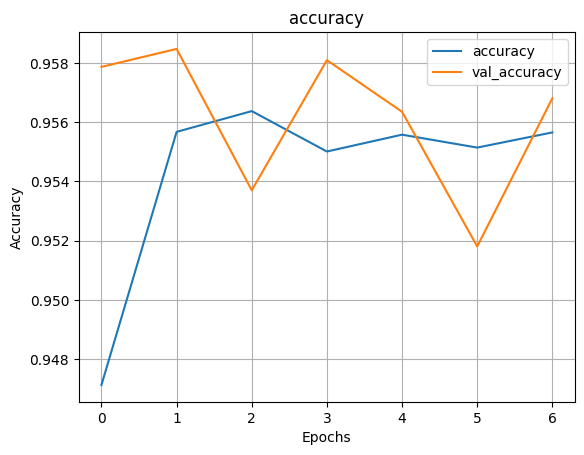

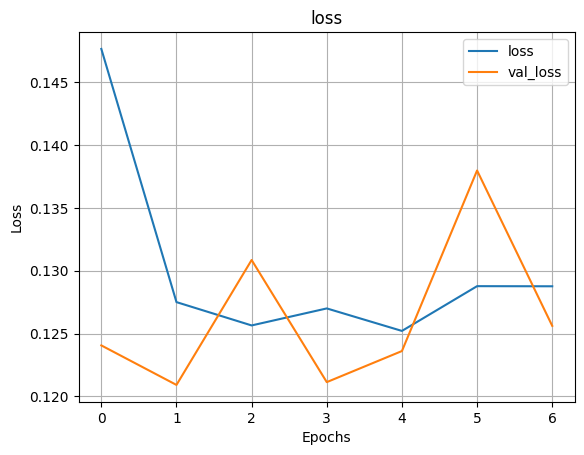

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 634us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.95     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



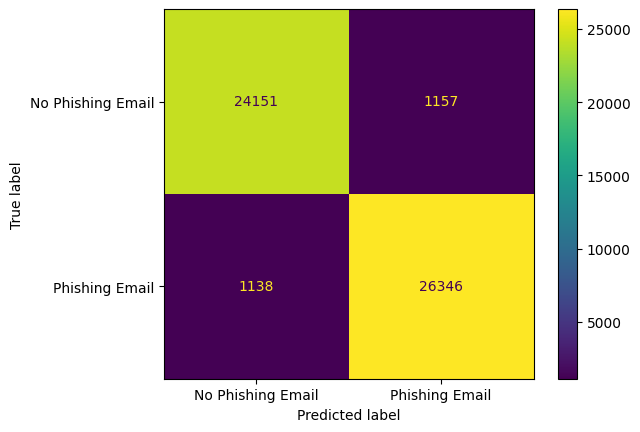

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



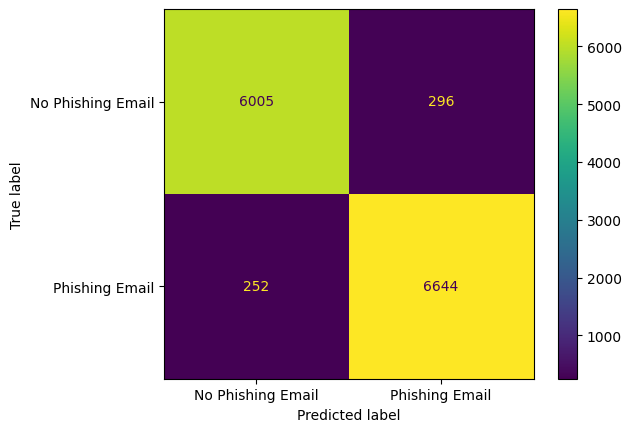


Config: layers=[64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9449 - loss: 0.1665 - val_accuracy: 0.9571 - val_loss: 0.1205
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9552 - loss: 0.1271 - val_accuracy: 0.9583 - val_loss: 0.1210
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1205, stopped at epoch 2

Print History


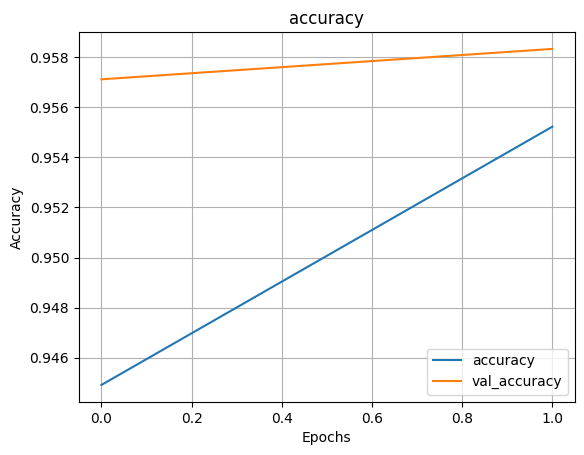

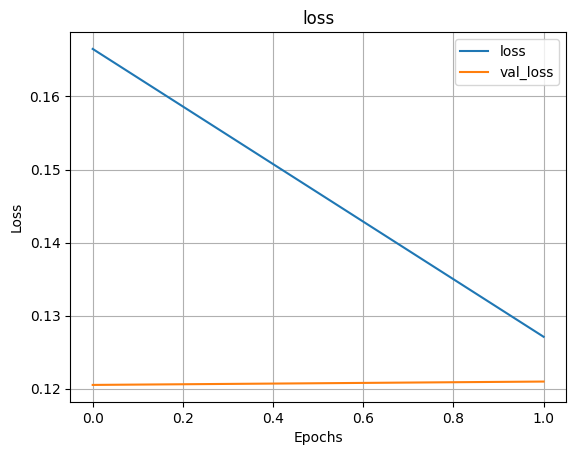

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 633us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.95     25308
   Phishing Email       0.95      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



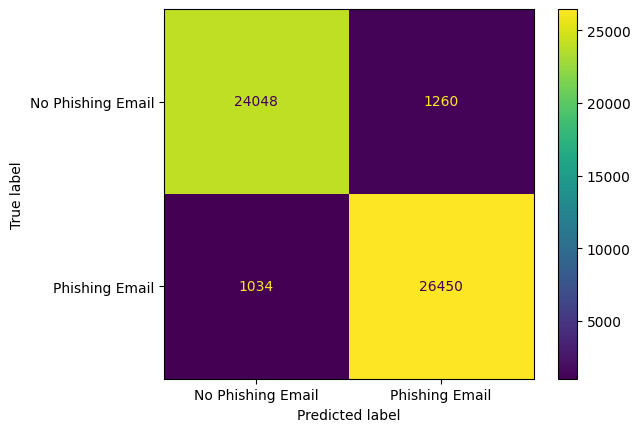

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.95      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



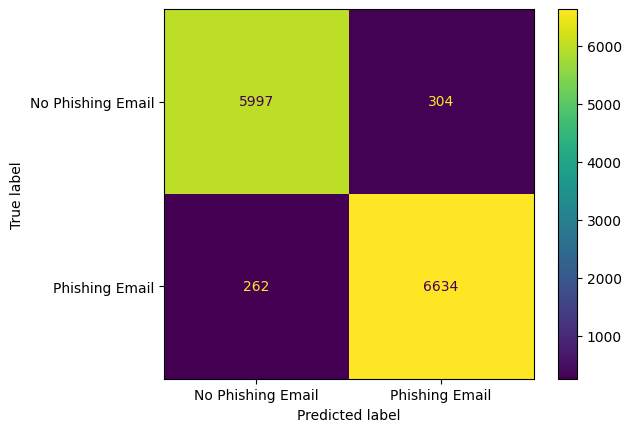


Config: layers=[64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9468 - loss: 0.1486 - val_accuracy: 0.9571 - val_loss: 0.1249
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9562 - loss: 0.1251 - val_accuracy: 0.9554 - val_loss: 0.1229
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1240 - val_accuracy: 0.9576 - val_loss: 0.1209
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9567 - loss: 0.1255 - val_accuracy: 0.9573 - val_loss: 0.1280
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1242 - val_accuracy: 0.9563 - val_loss: 0.1280
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9554 - loss: 0.1249 - val_accuracy: 0.9576 - val_loss: 0.1278
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1209, stopped at epoch 6

Print History


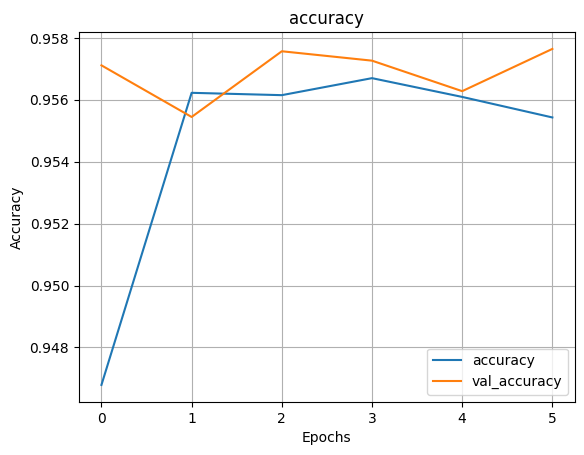

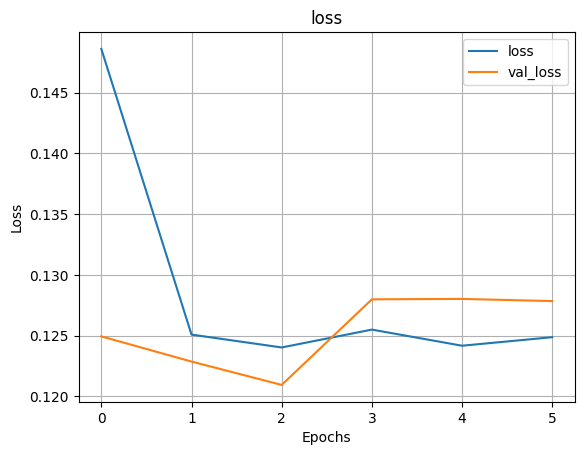

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



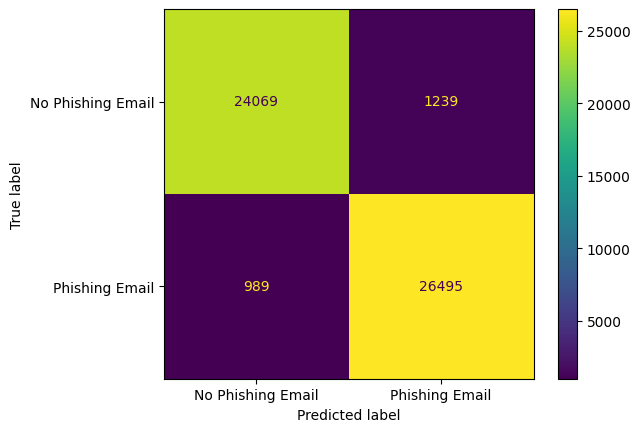

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.95      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



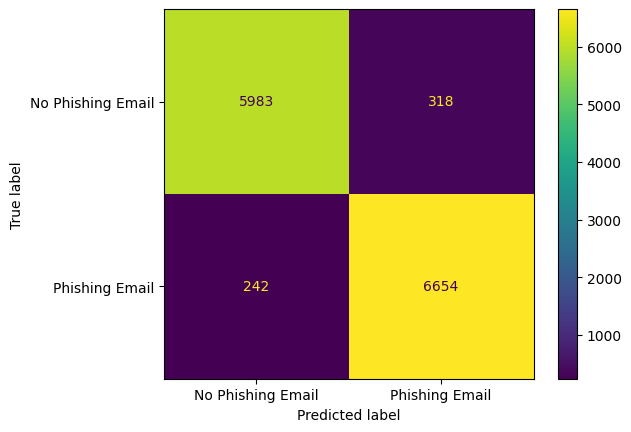


Config: layers=[64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9462 - loss: 0.1508 - val_accuracy: 0.9564 - val_loss: 0.1270
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9560 - loss: 0.1265 - val_accuracy: 0.9588 - val_loss: 0.1216
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1256 - val_accuracy: 0.9572 - val_loss: 0.1283
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9550 - loss: 0.1288 - val_accuracy: 0.9577 - val_loss: 0.1201
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9552 - loss: 0.1268 - val_accuracy: 0.9530 - val_loss: 0.1293
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9560 - loss: 0.1283 - val_accuracy: 0.9602 - val_loss: 0.1200
Epoch 7/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9563 - loss: 0.1278 - val_accuracy: 0.9560 - val_loss: 0.1296
Epoch 8/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9553 - loss: 0.1297 - val_accuracy: 0.9569 - val_loss: 0.1293
Epoch 9/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9546 - loss: 0.1313 - val_accuracy: 0.9596 - val

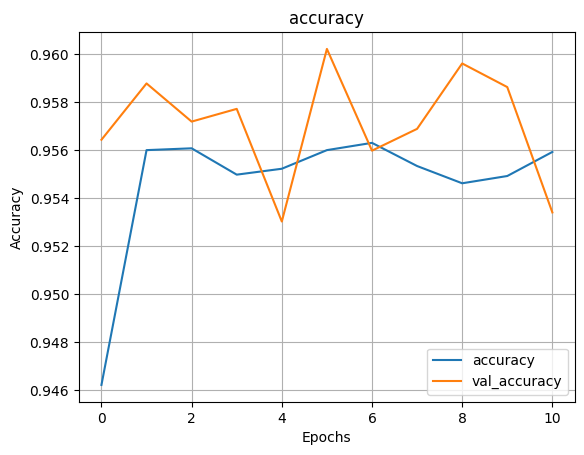

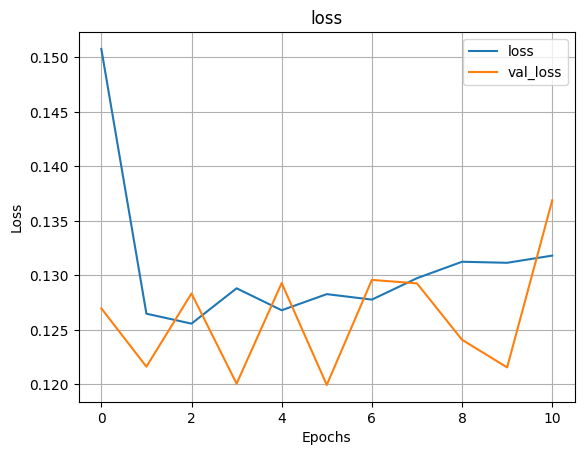

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



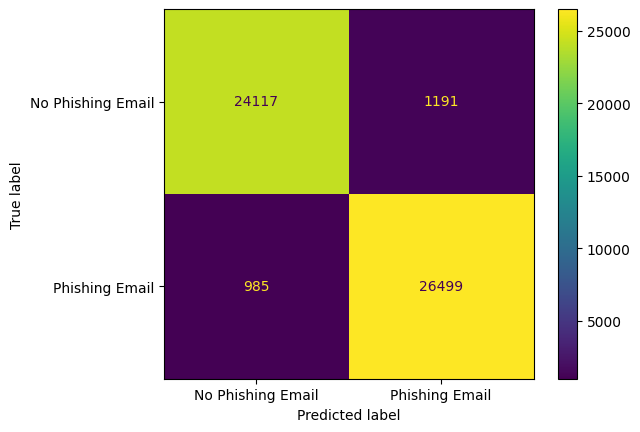

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



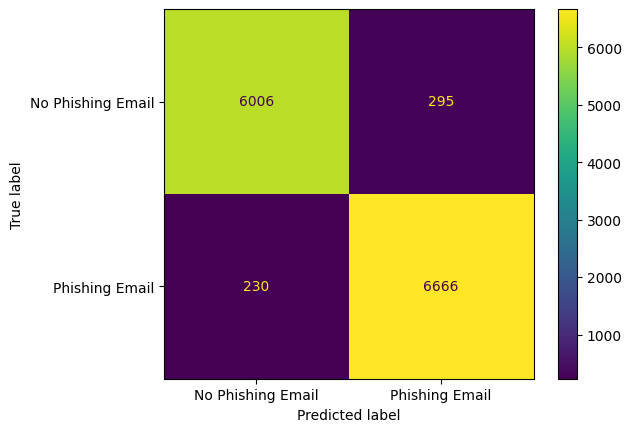


Config: layers=[64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 8s - 5ms/step - accuracy: 0.9484 - loss: 0.1480 - val_accuracy: 0.9589 - val_loss: 0.1274
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9557 - loss: 0.1268 - val_accuracy: 0.9592 - val_loss: 0.1216
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9547 - loss: 0.1273 - val_accuracy: 0.9584 - val_loss: 0.1193
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9547 - loss: 0.1289 - val_accuracy: 0.9592 - val_loss: 0.1214
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1193, stopped at epoch 4

Print History


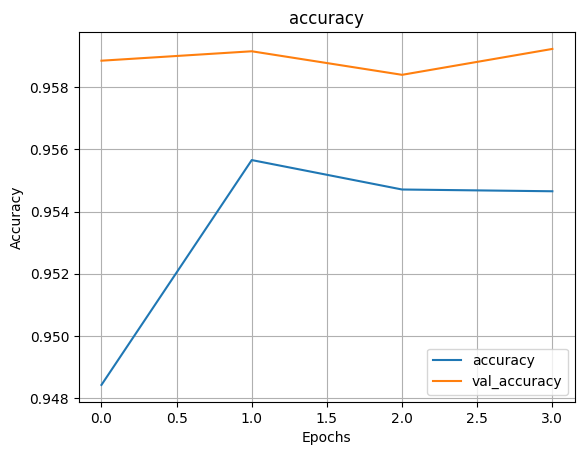

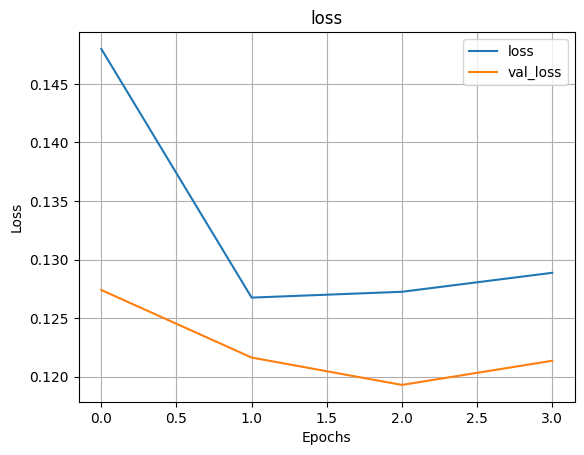

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 631us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



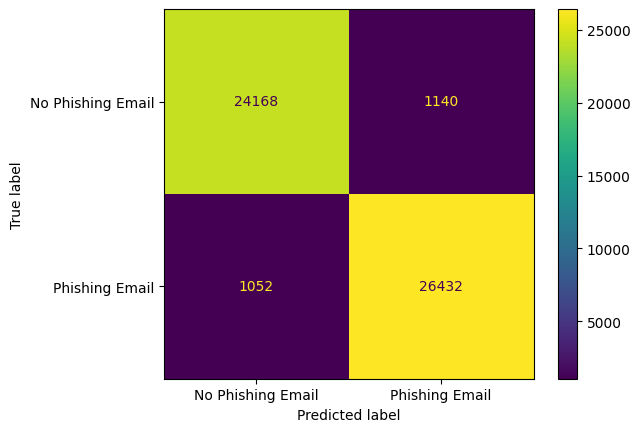

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



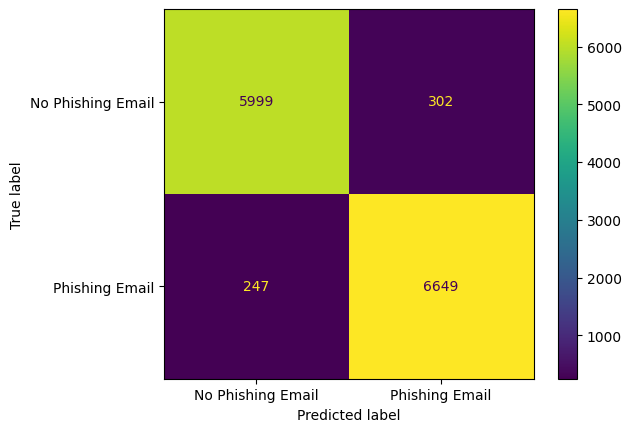


Config: layers=[64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9494 - loss: 0.1429 - val_accuracy: 0.9574 - val_loss: 0.1259
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9562 - loss: 0.1269 - val_accuracy: 0.9559 - val_loss: 0.1245
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1252 - val_accuracy: 0.9607 - val_loss: 0.1167
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9559 - loss: 0.1250 - val_accuracy: 0.9569 - val_loss: 0.1260
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9561 - loss: 0.1259 - val_accuracy: 0.9564 - val_loss: 0.1264
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9558 - loss: 0.1274 - val_accuracy: 0.9565 - val_loss: 0.1234
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Finished. Best val_loss=0.1167, stopped at epoch 6

Print History


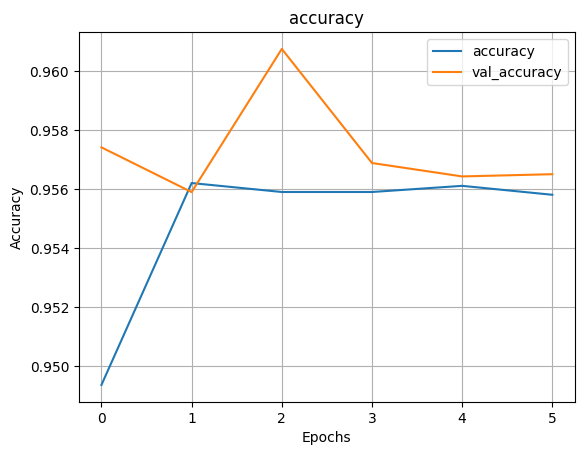

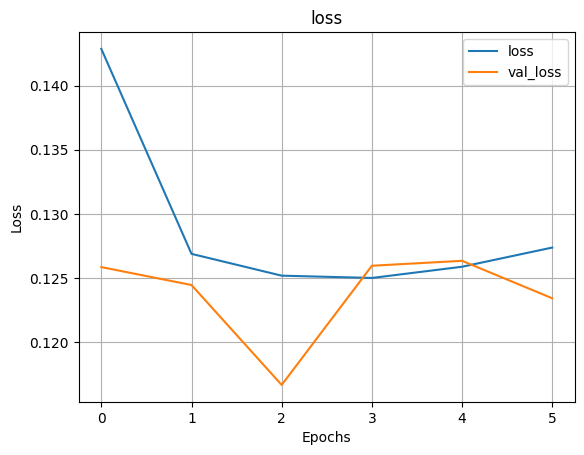

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 632us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.96      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



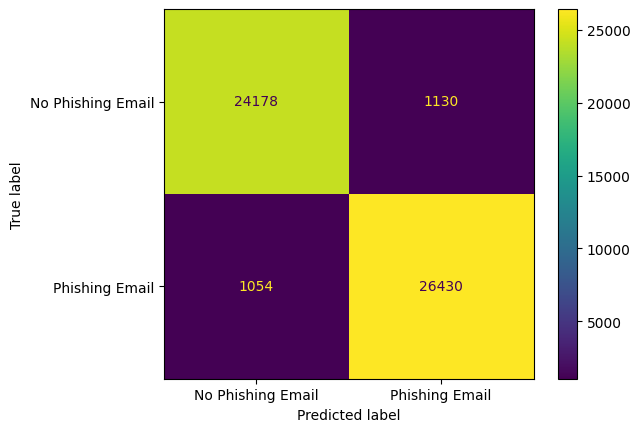

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.97      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



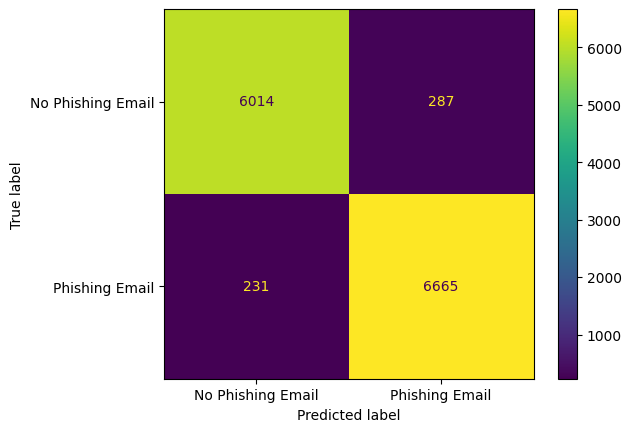


Config: layers=[64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 9s - 5ms/step - accuracy: 0.9498 - loss: 0.1428 - val_accuracy: 0.9586 - val_loss: 0.1198
Epoch 2/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9566 - loss: 0.1249 - val_accuracy: 0.9555 - val_loss: 0.1231
Epoch 3/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9563 - loss: 0.1256 - val_accuracy: 0.9584 - val_loss: 0.1215
Epoch 4/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9565 - loss: 0.1251 - val_accuracy: 0.9583 - val_loss: 0.1211
Epoch 5/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9564 - loss: 0.1253 - val_accuracy: 0.9570 - val_loss: 0.1231
Epoch 6/100
1650/1650 - 8s - 5ms/step - accuracy: 0.9564 - loss: 0.1256 - val_accuracy: 0.9560 - val_loss: 0.1317
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1198, stopped at epoch 6

Print History


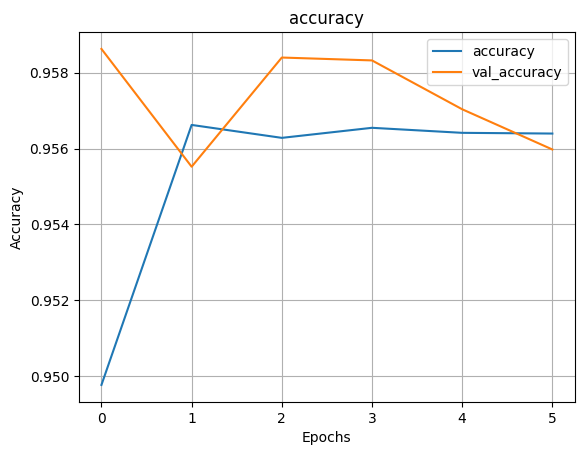

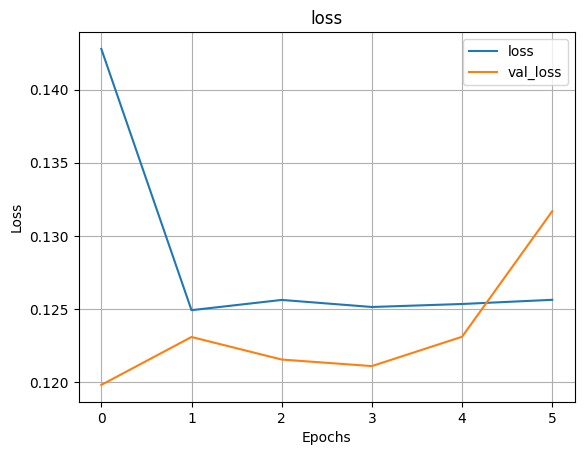

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 633us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96     25308
   Phishing Email       0.96      0.96      0.96     27484

         accuracy                           0.96     52792
        macro avg       0.96      0.96      0.96     52792
     weighted avg       0.96      0.96      0.96     52792



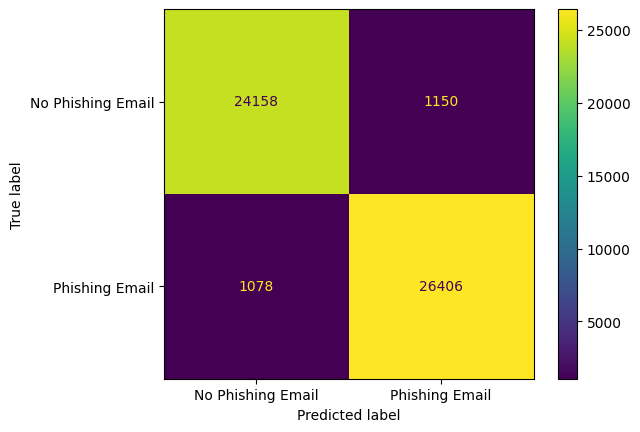

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.95      0.96      6301
   Phishing Email       0.96      0.96      0.96      6896

         accuracy                           0.96     13197
        macro avg       0.96      0.96      0.96     13197
     weighted avg       0.96      0.96      0.96     13197



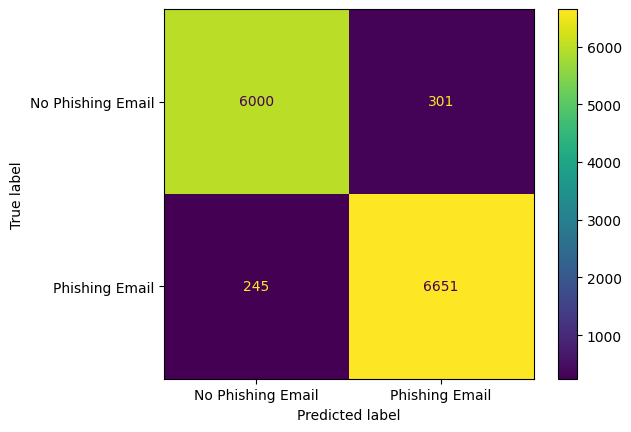


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9400 - loss: 0.1982 - val_accuracy: 0.9529 - val_loss: 0.1947
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9238 - loss: 0.7221 - val_accuracy: 0.9456 - val_loss: 0.6834
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1947, stopped at epoch 2

Print History


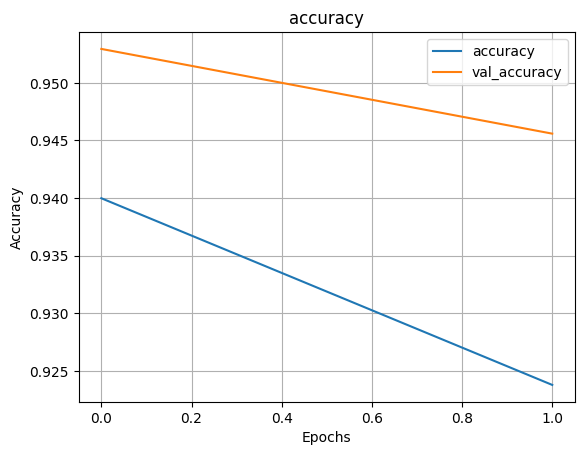

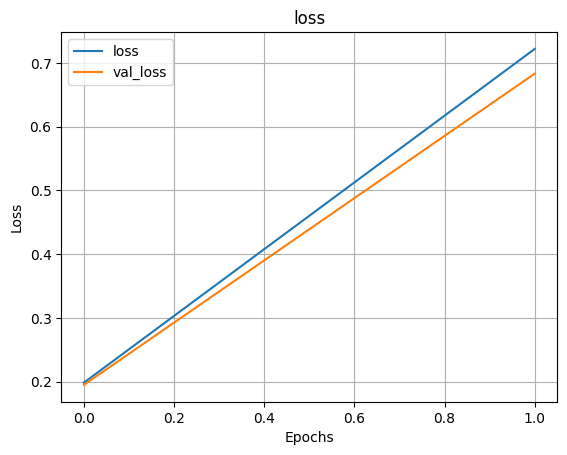

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.96      0.95     25308
   Phishing Email       0.96      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



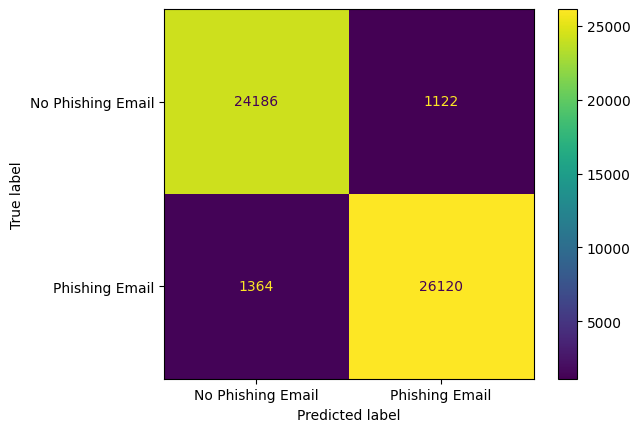

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.96      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



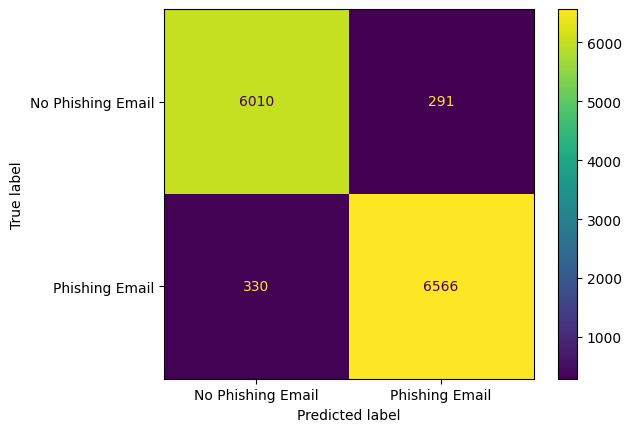


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9398 - loss: 0.1876 - val_accuracy: 0.9255 - val_loss: 0.5547
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9324 - loss: 0.3952 - val_accuracy: 0.9527 - val_loss: 0.3139
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9273 - loss: 0.7593 - val_accuracy: 0.9455 - val_loss: 0.6502
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9268 - loss: 1.2437 - val_accuracy: 0.9473 - val_loss: 0.9347
Epoch 5/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9259 - loss: 1.7549 - val_accuracy: 0.9455 - val_loss: 1.4779
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Finished. Best val_loss=0.3139, stopped at epoch 5

Print History


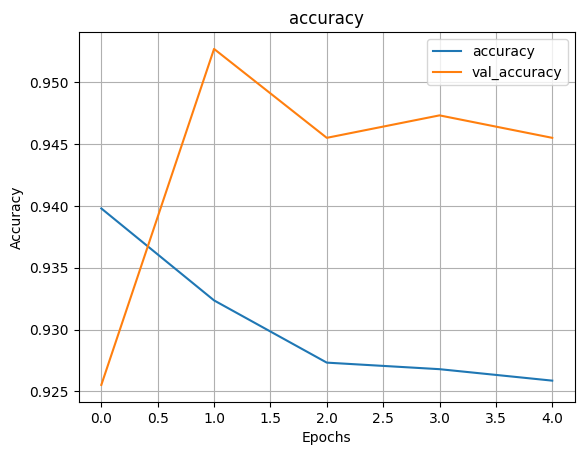

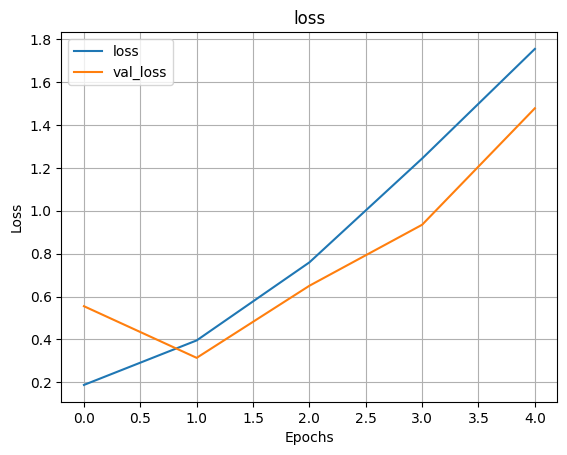

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 658us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.96      0.95     25308
   Phishing Email       0.96      0.94      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



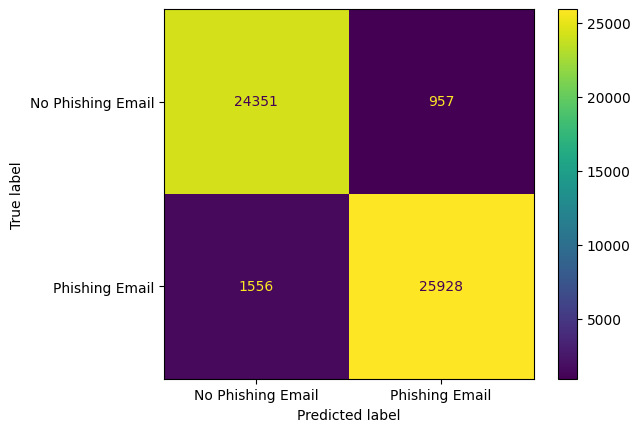

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.96      0.95      6301
   Phishing Email       0.96      0.94      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



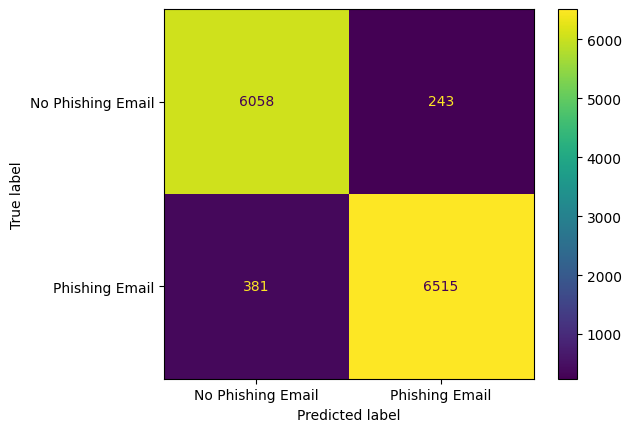


Config: layers=[128, 64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9436 - loss: 0.1692 - val_accuracy: 0.9523 - val_loss: 0.1490
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9330 - loss: 0.3274 - val_accuracy: 0.9260 - val_loss: 0.4802
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9276 - loss: 0.6767 - val_accuracy: 0.9239 - val_loss: 0.8601
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9267 - loss: 1.0168 - val_accuracy: 0.9501 - val_loss: 0.7541
Epoch 5/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9257 - loss: 1.5920 - val_accuracy: 0.9548 - val_loss: 0.9276
Epoch 6/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9275 - loss: 2.1705 - val_accuracy: 0.9399 - val_loss: 1.6147
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1490, stopped at epoch 6

Print History


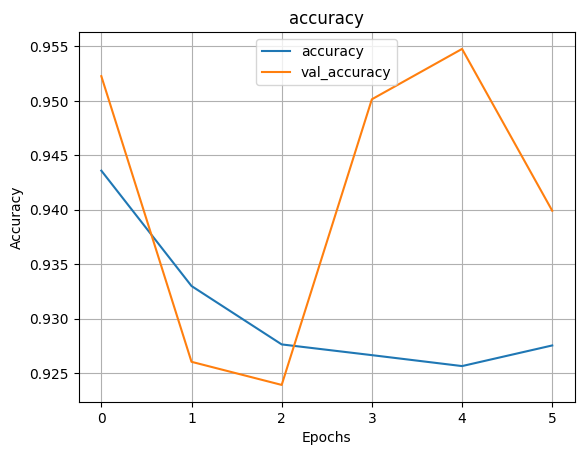

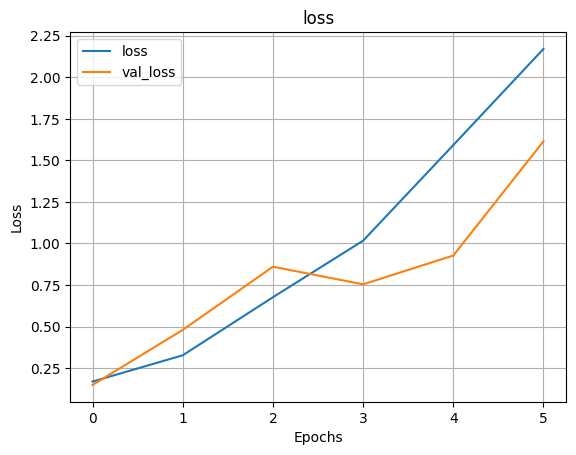

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95     25308
   Phishing Email       0.95      0.96      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



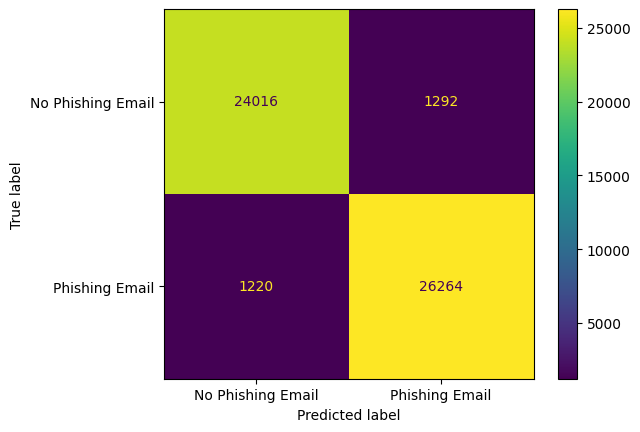

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.94      0.95      6301
   Phishing Email       0.95      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



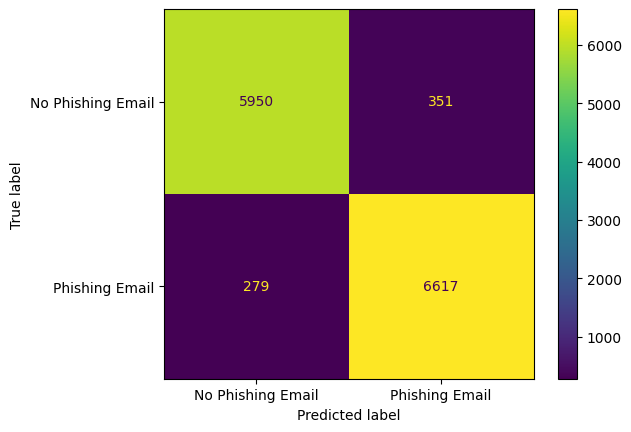


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9396 - loss: 0.1899 - val_accuracy: 0.9526 - val_loss: 0.1895
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9286 - loss: 0.4916 - val_accuracy: 0.9149 - val_loss: 0.9430
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1895, stopped at epoch 2

Print History


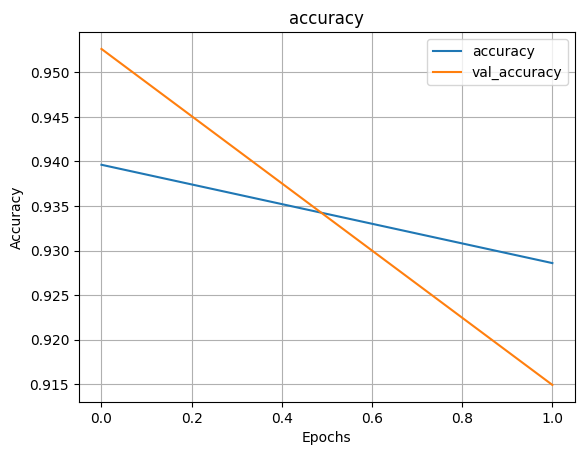

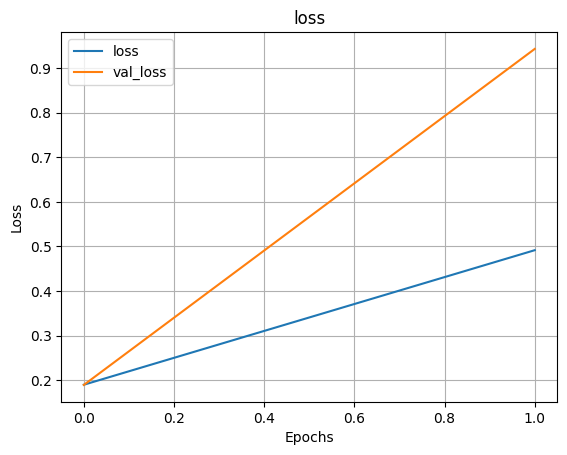

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95     25308
   Phishing Email       0.95      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



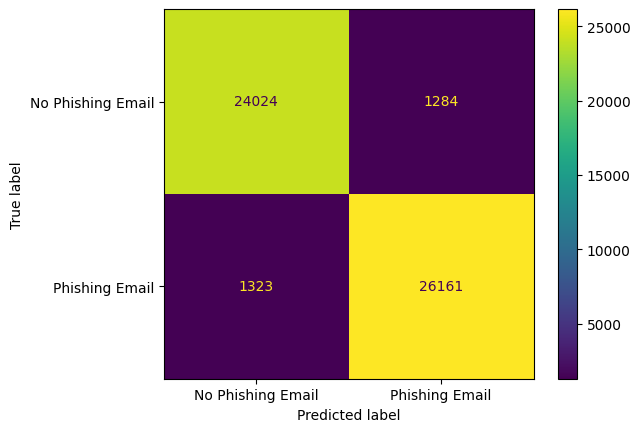

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.95      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



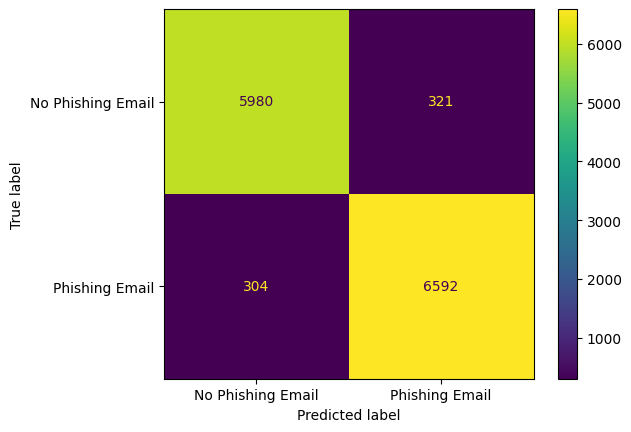


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9427 - loss: 0.1774 - val_accuracy: 0.9467 - val_loss: 0.1703
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9295 - loss: 0.4623 - val_accuracy: 0.9137 - val_loss: 0.7836
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9290 - loss: 0.9575 - val_accuracy: 0.8888 - val_loss: 2.6190
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9273 - loss: 1.4008 - val_accuracy: 0.9361 - val_loss: 1.1547
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1703, stopped at epoch 4

Print History


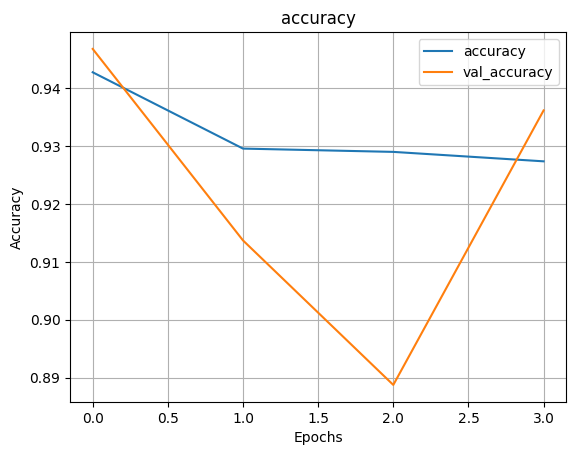

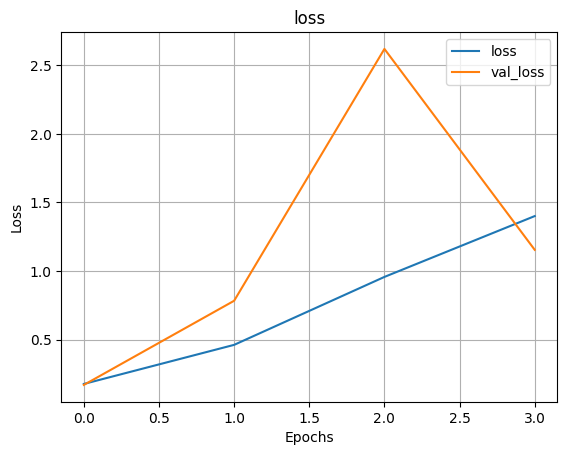

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.94     25308
   Phishing Email       0.95      0.94      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



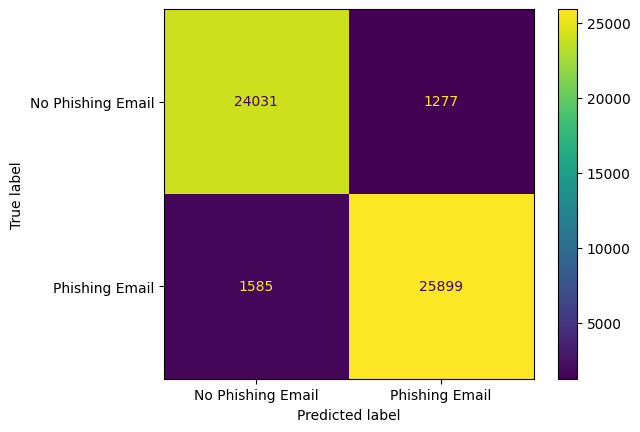

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.94      6301
   Phishing Email       0.95      0.94      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



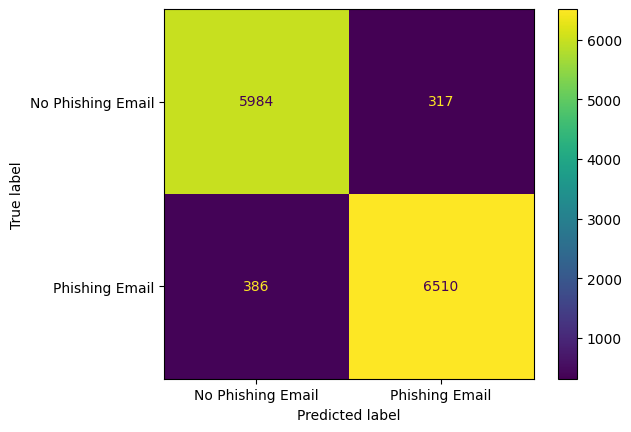


Config: layers=[128, 64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9427 - loss: 0.1694 - val_accuracy: 0.9251 - val_loss: 0.3016
Epoch 2/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9310 - loss: 0.3981 - val_accuracy: 0.9044 - val_loss: 0.7651
Epoch 3/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9269 - loss: 0.7539 - val_accuracy: 0.9460 - val_loss: 0.6148
Epoch 4/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9262 - loss: 1.2340 - val_accuracy: 0.9507 - val_loss: 0.8606
Epoch 5/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9233 - loss: 1.9876 - val_accuracy: 0.9044 - val_loss: 3.2246
Epoch 6/50
1650/1650 - 9s - 6ms/step - accuracy: 0.9250 - loss: 2.6570 - val_accuracy: 0.9576 - val_loss: 1.4646
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.3016, stopped at epoch 6

Print History


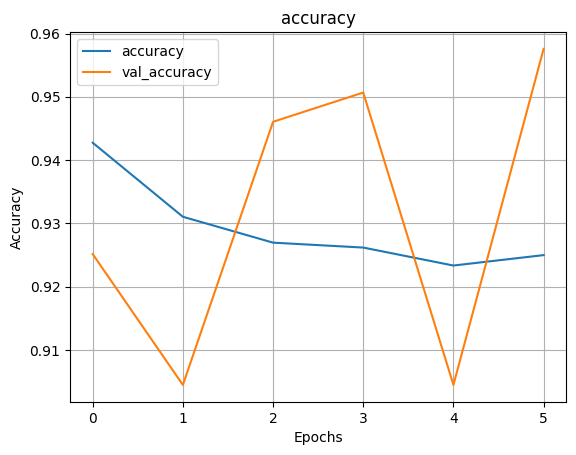

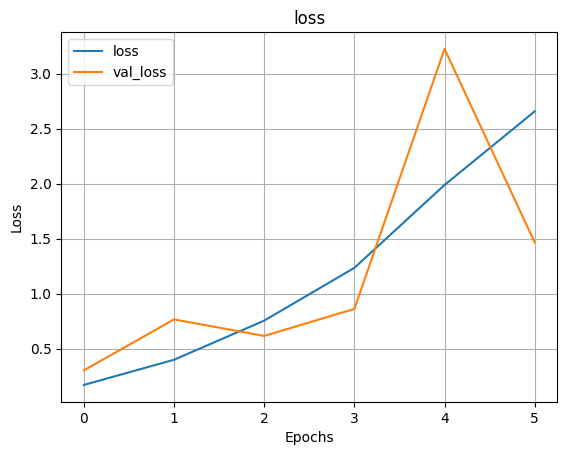

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.93      0.92     25308
   Phishing Email       0.93      0.92      0.93     27484

         accuracy                           0.93     52792
        macro avg       0.92      0.93      0.92     52792
     weighted avg       0.93      0.93      0.93     52792



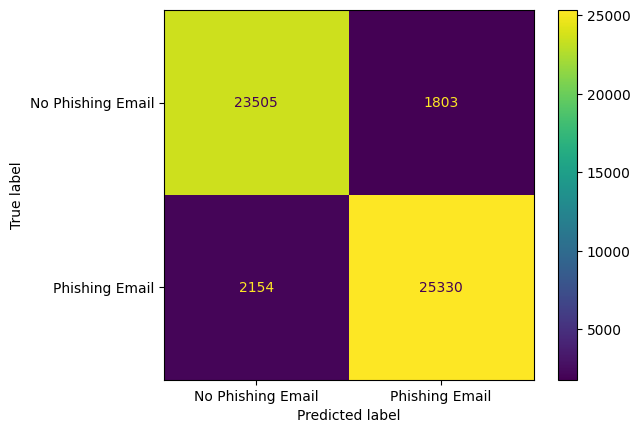

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step
                   precision    recall  f1-score   support

No Phishing Email       0.92      0.93      0.92      6301
   Phishing Email       0.93      0.92      0.93      6896

         accuracy                           0.93     13197
        macro avg       0.92      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



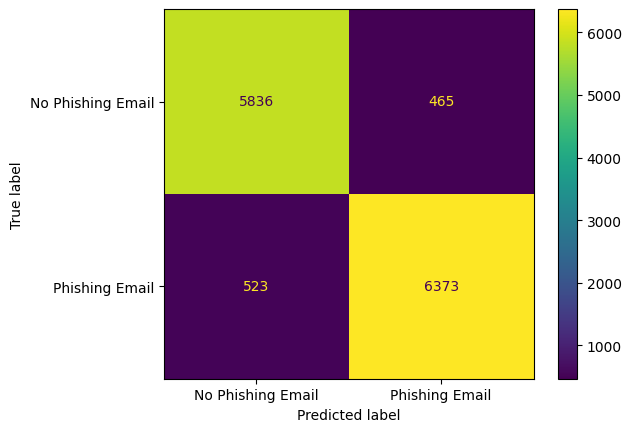


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9426 - loss: 0.1718 - val_accuracy: 0.9464 - val_loss: 0.1752
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9292 - loss: 0.3961 - val_accuracy: 0.9433 - val_loss: 0.4269
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1752, stopped at epoch 2

Print History


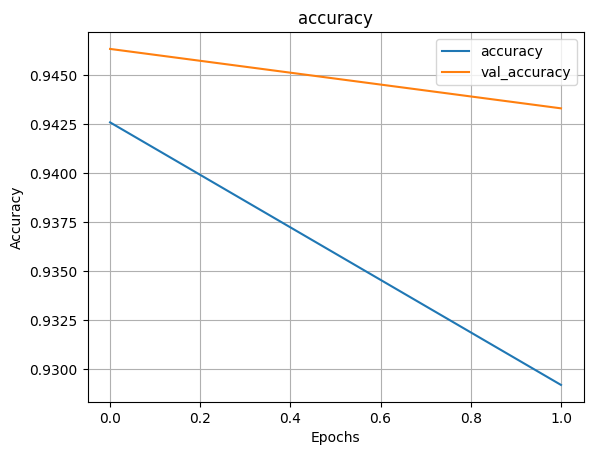

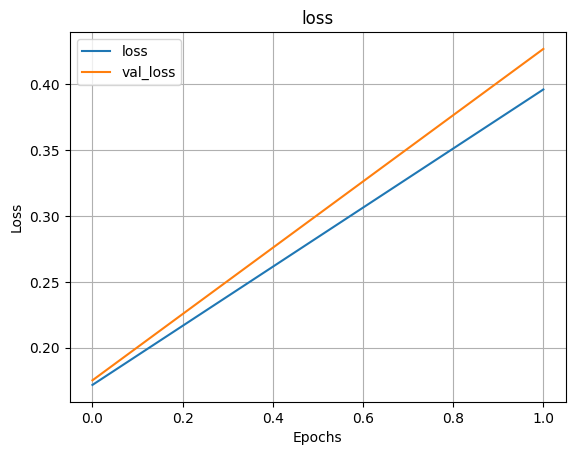

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.94     25308
   Phishing Email       0.95      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



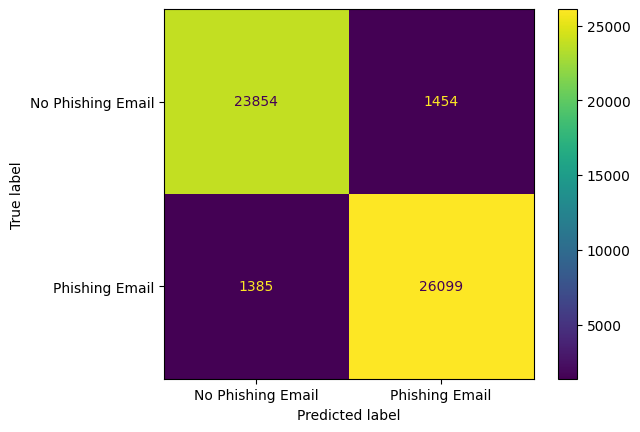

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.94      6301
   Phishing Email       0.94      0.95      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



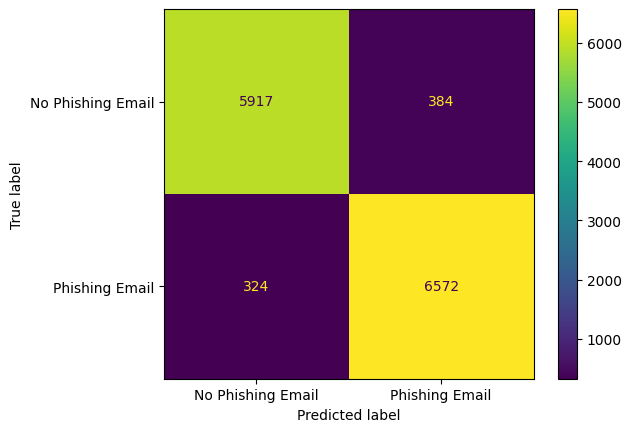


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9404 - loss: 0.1911 - val_accuracy: 0.9254 - val_loss: 0.2840
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9225 - loss: 0.6014 - val_accuracy: 0.9330 - val_loss: 0.7408
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9227 - loss: 1.1711 - val_accuracy: 0.9016 - val_loss: 2.0573
Epoch 4/100
1650/1650 - 91s - 55ms/step - accuracy: 0.9233 - loss: 1.7931 - val_accuracy: 0.9542 - val_loss: 1.1190
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.2840, stopped at epoch 4

Print History


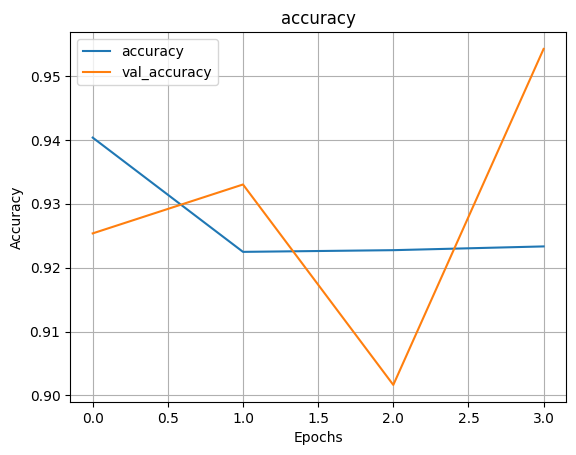

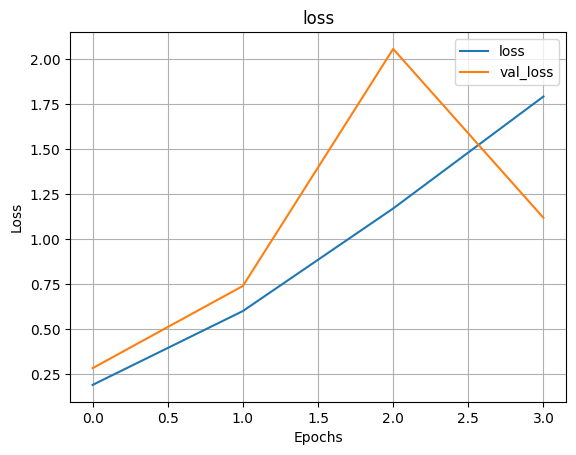

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 655us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.94      0.92     25308
   Phishing Email       0.94      0.91      0.93     27484

         accuracy                           0.92     52792
        macro avg       0.92      0.93      0.92     52792
     weighted avg       0.93      0.92      0.92     52792



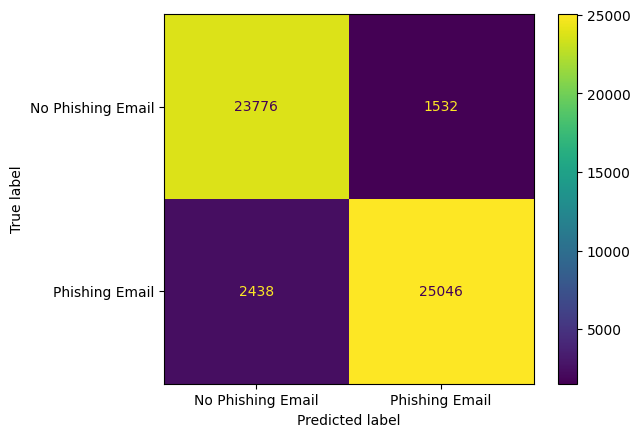

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step
                   precision    recall  f1-score   support

No Phishing Email       0.91      0.94      0.92      6301
   Phishing Email       0.94      0.92      0.93      6896

         accuracy                           0.93     13197
        macro avg       0.93      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



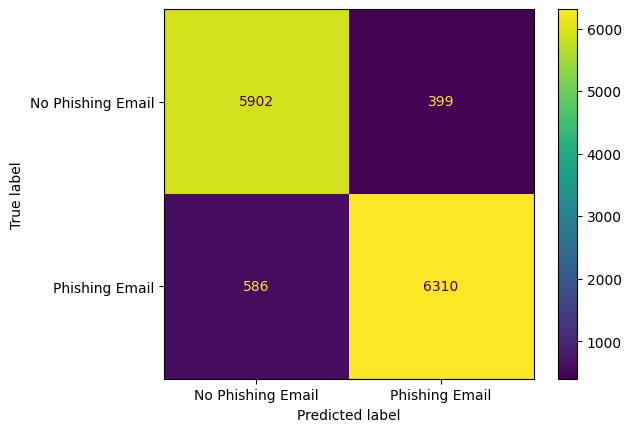


Config: layers=[128, 64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9411 - loss: 0.1817 - val_accuracy: 0.9517 - val_loss: 0.1782
Epoch 2/100
1650/1650 - 10s - 6ms/step - accuracy: 0.9294 - loss: 0.4301 - val_accuracy: 0.9452 - val_loss: 0.4346
Epoch 3/100
1650/1650 - 10s - 6ms/step - accuracy: 0.9243 - loss: 0.9782 - val_accuracy: 0.9426 - val_loss: 0.7931
Epoch 4/100
1650/1650 - 10s - 6ms/step - accuracy: 0.9230 - loss: 1.6278 - val_accuracy: 0.9432 - val_loss: 1.2215
Epoch 5/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9282 - loss: 2.1281 - val_accuracy: 0.8594 - val_loss: 6.7635
Epoch 6/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9228 - loss: 3.1543 - val_accuracy: 0.9568 - val_loss: 1.6104
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1782, stopped at epoch 6

Print History


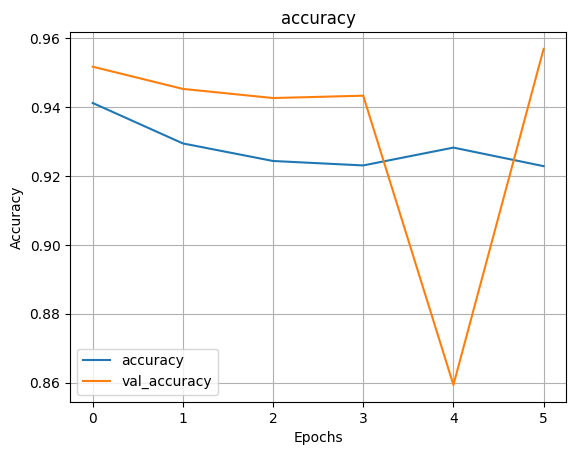

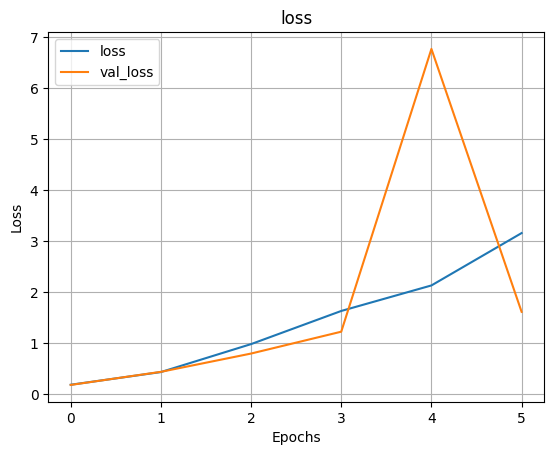

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 655us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95     25308
   Phishing Email       0.95      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



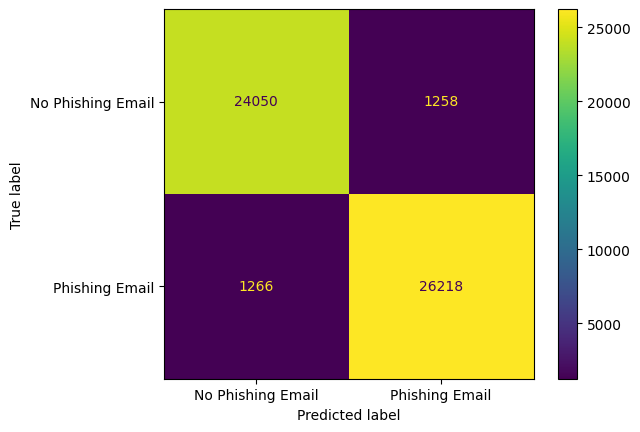

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.95      0.95      6301
   Phishing Email       0.95      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



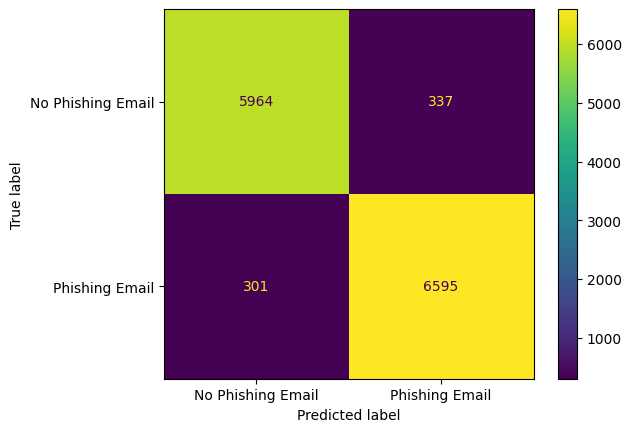


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9415 - loss: 0.1818 - val_accuracy: 0.9442 - val_loss: 0.1846
Epoch 2/100
1650/1650 - 10s - 6ms/step - accuracy: 0.9300 - loss: 0.3820 - val_accuracy: 0.9310 - val_loss: 0.4390
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1846, stopped at epoch 2

Print History


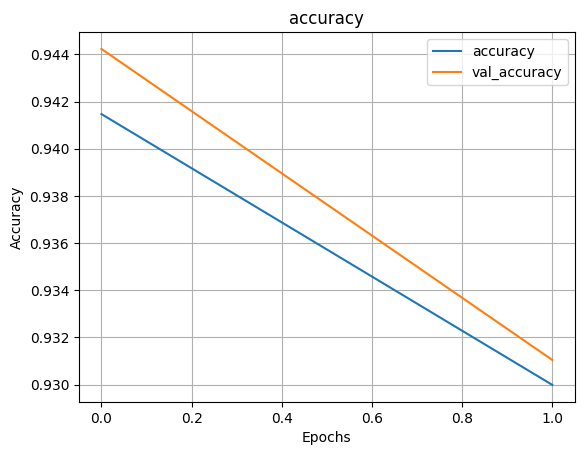

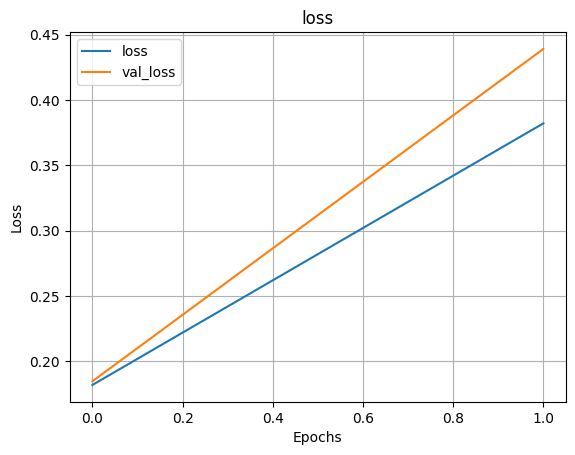

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.95      0.94     25308
   Phishing Email       0.95      0.94      0.95     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



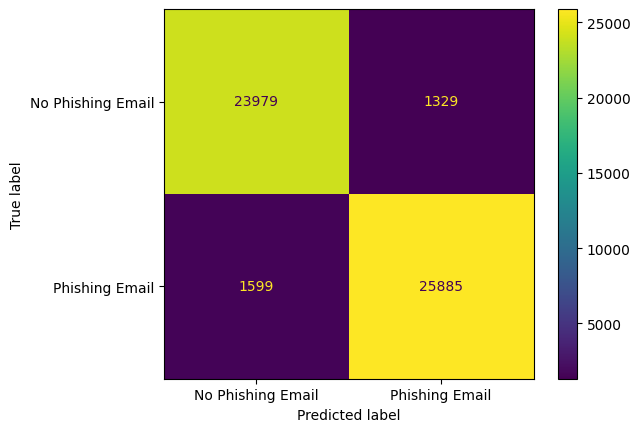

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step
                   precision    recall  f1-score   support

No Phishing Email       0.94      0.94      0.94      6301
   Phishing Email       0.95      0.95      0.95      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



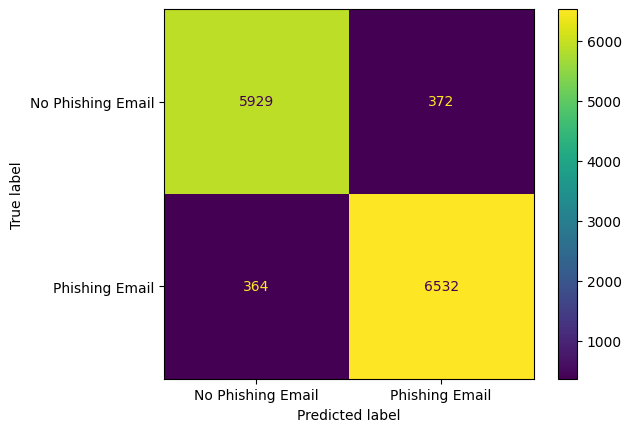


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9416 - loss: 0.1780 - val_accuracy: 0.9484 - val_loss: 0.1760
Epoch 2/100
1650/1650 - 10s - 6ms/step - accuracy: 0.9318 - loss: 0.3850 - val_accuracy: 0.9533 - val_loss: 0.3193
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9224 - loss: 0.8894 - val_accuracy: 0.9210 - val_loss: 1.3017
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9246 - loss: 1.5640 - val_accuracy: 0.9523 - val_loss: 0.9528
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.1760, stopped at epoch 4

Print History


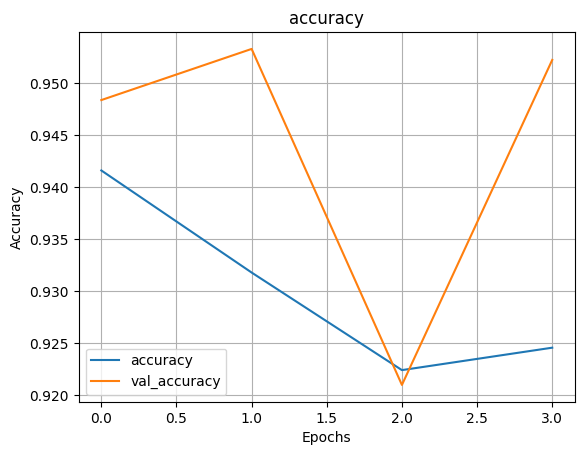

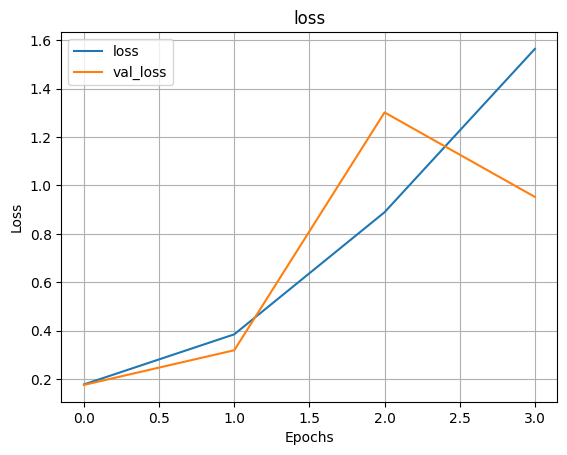

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 658us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.94     25308
   Phishing Email       0.95      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



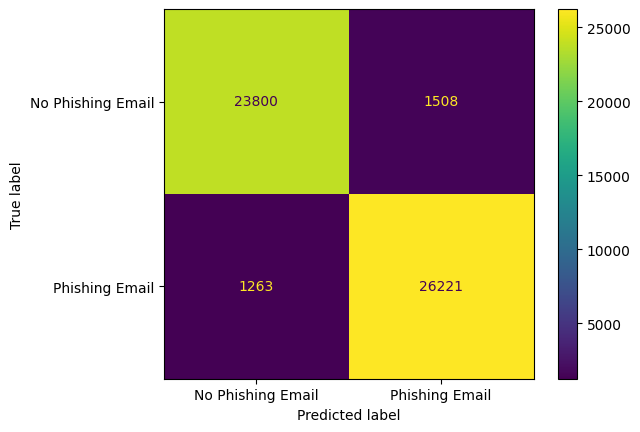

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.95      6301
   Phishing Email       0.94      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



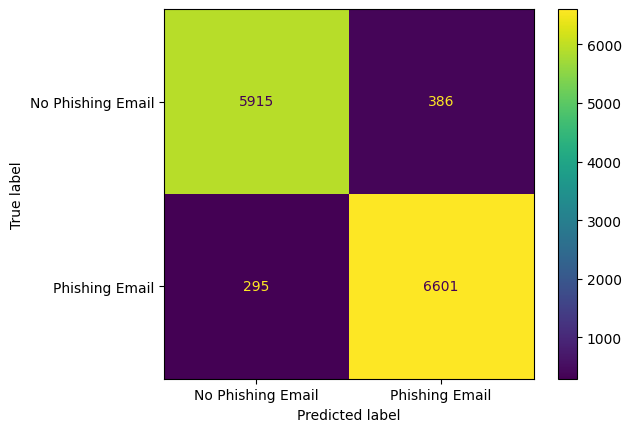


Config: layers=[128, 64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 10s - 6ms/step - accuracy: 0.9402 - loss: 0.1853 - val_accuracy: 0.9361 - val_loss: 0.3578
Epoch 2/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9287 - loss: 0.3883 - val_accuracy: 0.8540 - val_loss: 1.3040
Epoch 3/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9263 - loss: 0.8274 - val_accuracy: 0.9451 - val_loss: 0.7277
Epoch 4/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9246 - loss: 1.5003 - val_accuracy: 0.9387 - val_loss: 1.1553
Epoch 5/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9216 - loss: 2.4280 - val_accuracy: 0.9367 - val_loss: 2.5561
Epoch 6/100
1650/1650 - 9s - 6ms/step - accuracy: 0.9268 - loss: 2.9875 - val_accuracy: 0.9454 - val_loss: 2.2601
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=0.3578, stopped at epoch 6

Print History


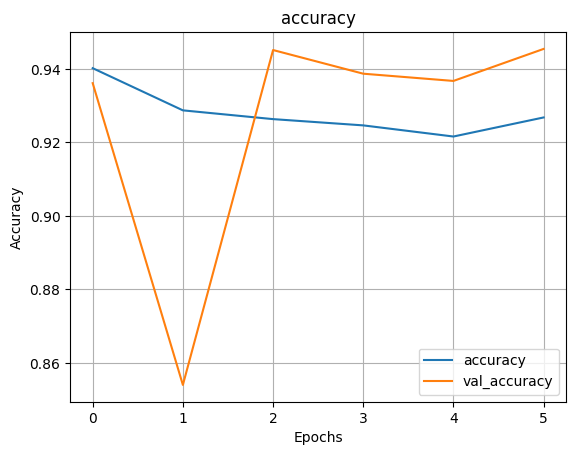

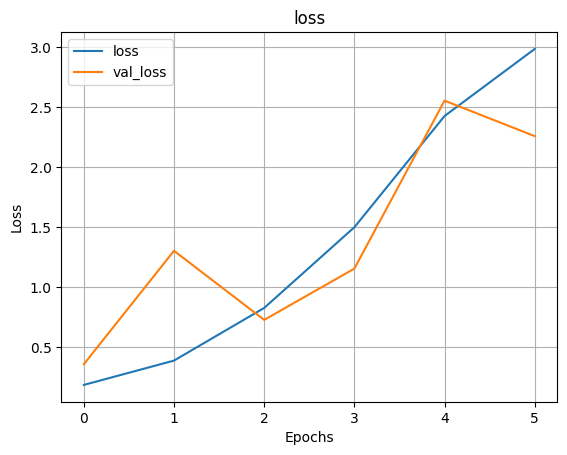

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.92      0.93     25308
   Phishing Email       0.93      0.95      0.94     27484

         accuracy                           0.94     52792
        macro avg       0.94      0.94      0.94     52792
     weighted avg       0.94      0.94      0.94     52792



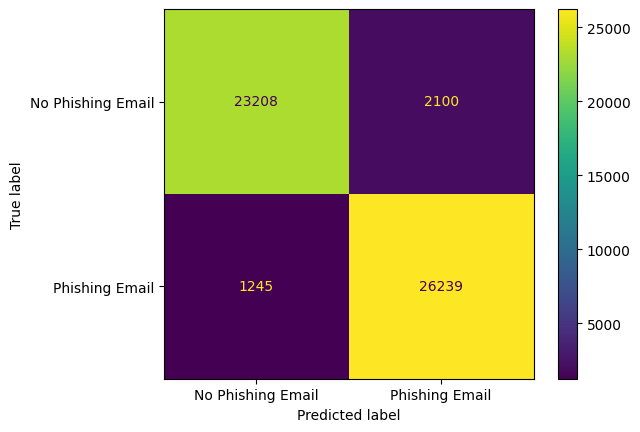

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.92      0.93      6301
   Phishing Email       0.93      0.96      0.94      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



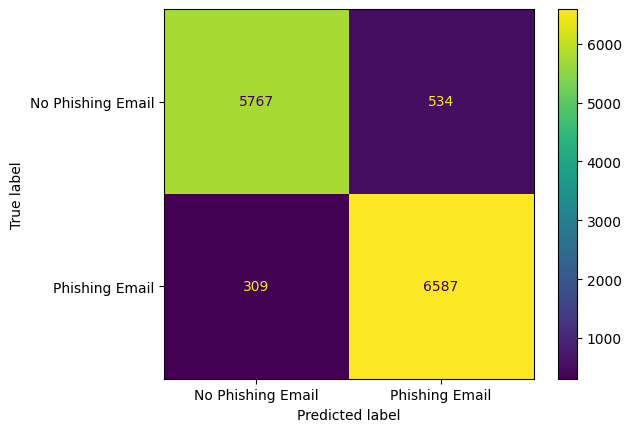


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8998 - loss: 25.8174 - val_accuracy: 0.9471 - val_loss: 52.2127
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.8997 - loss: 284.9043 - val_accuracy: 0.7464 - val_loss: 1506.2930
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=52.2127, stopped at epoch 2

Print History


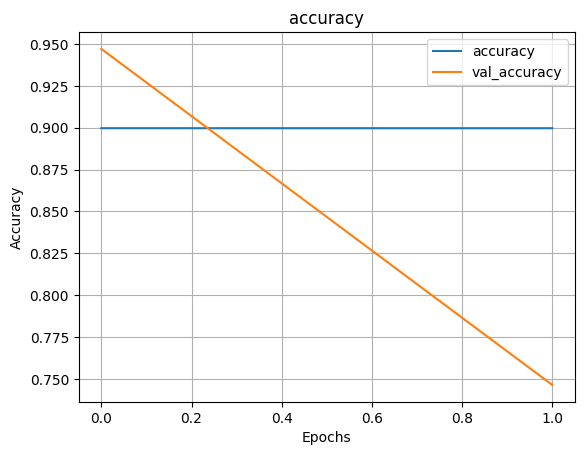

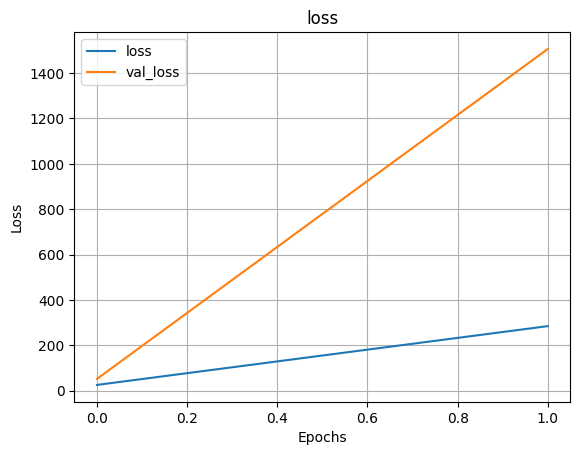

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 680us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.93      0.94     25308
   Phishing Email       0.94      0.96      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



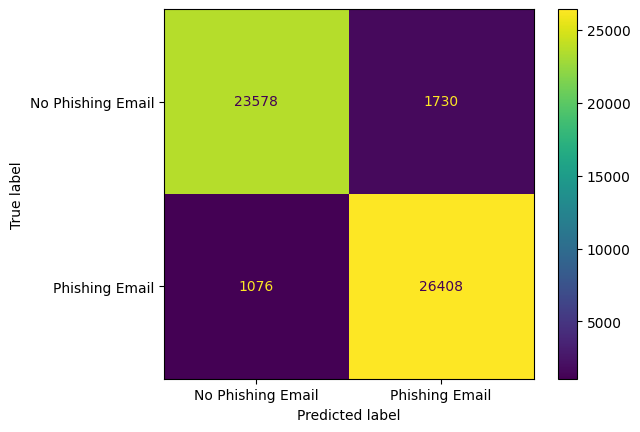

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.93      0.94      6301
   Phishing Email       0.94      0.96      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



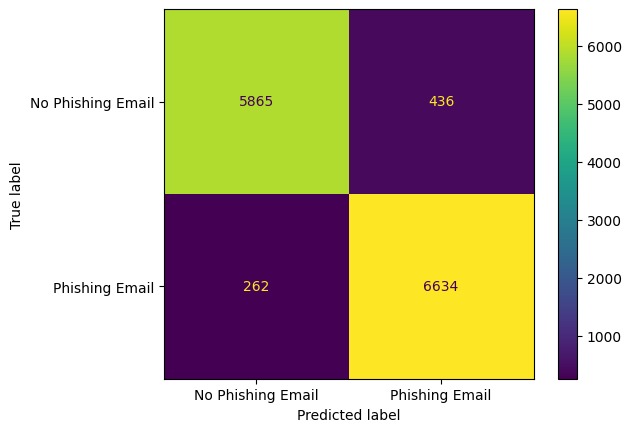


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.8990 - loss: 28.2521 - val_accuracy: 0.9324 - val_loss: 89.9100
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9029 - loss: 276.8392 - val_accuracy: 0.9307 - val_loss: 266.7630
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9012 - loss: 1059.3643 - val_accuracy: 0.7966 - val_loss: 5087.9297
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9087 - loss: 2067.2681 - val_accuracy: 0.8823 - val_loss: 2941.8433
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=89.9100, stopped at epoch 4

Print History


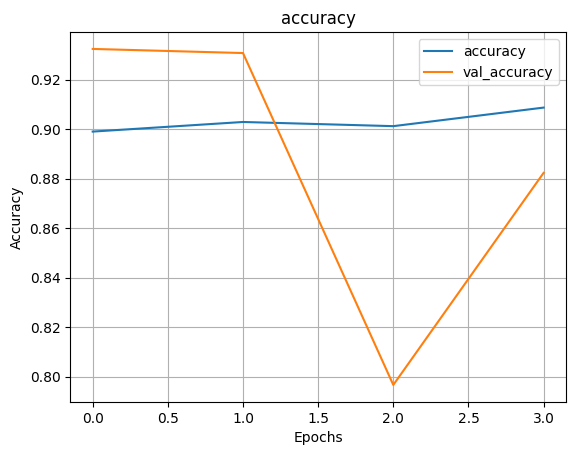

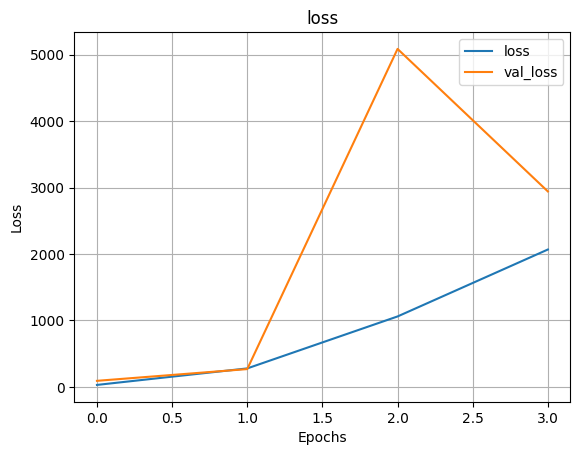

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.90      0.93     25308
   Phishing Email       0.91      0.96      0.94     27484

         accuracy                           0.93     52792
        macro avg       0.93      0.93      0.93     52792
     weighted avg       0.93      0.93      0.93     52792



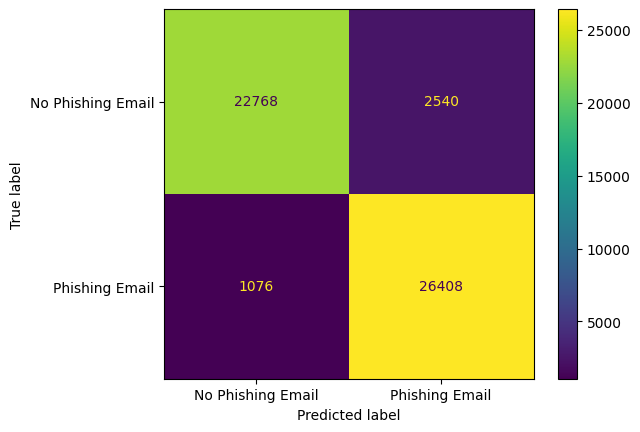

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step
                   precision    recall  f1-score   support

No Phishing Email       0.96      0.90      0.93      6301
   Phishing Email       0.91      0.96      0.94      6896

         accuracy                           0.93     13197
        macro avg       0.93      0.93      0.93     13197
     weighted avg       0.93      0.93      0.93     13197



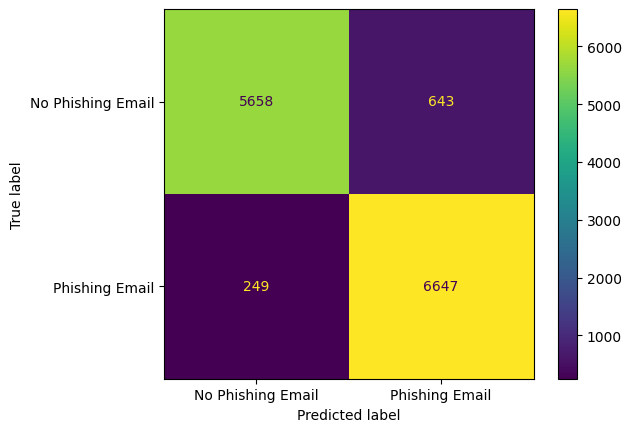


Config: layers=[256, 128, 64], epochs=50, min_delta=0.0, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8967 - loss: 35.6817 - val_accuracy: 0.7718 - val_loss: 297.4477
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9002 - loss: 363.1031 - val_accuracy: 0.9025 - val_loss: 514.3239
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9124 - loss: 886.3007 - val_accuracy: 0.9569 - val_loss: 338.1090
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9033 - loss: 2214.9795 - val_accuracy: 0.9241 - val_loss: 2020.8711
Epoch 5/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9148 - loss: 2800.1653 - val_accuracy: 0.9349 - val_loss: 1564.6816
Epoch 6/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9058 - loss: 4911.6919 - val_accuracy: 0.7897 - val_loss: 21733.6992
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=297.4477, stopped at epoch 6

Print History


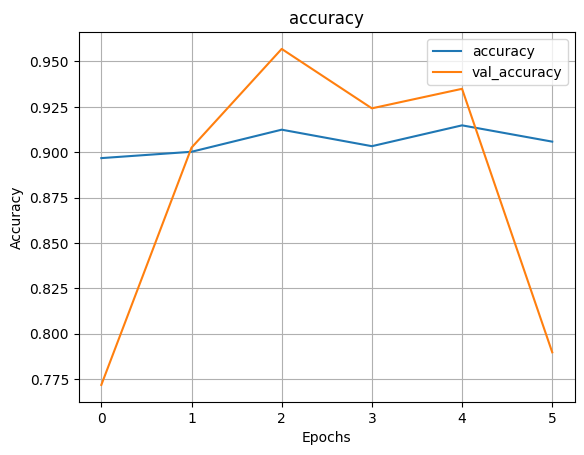

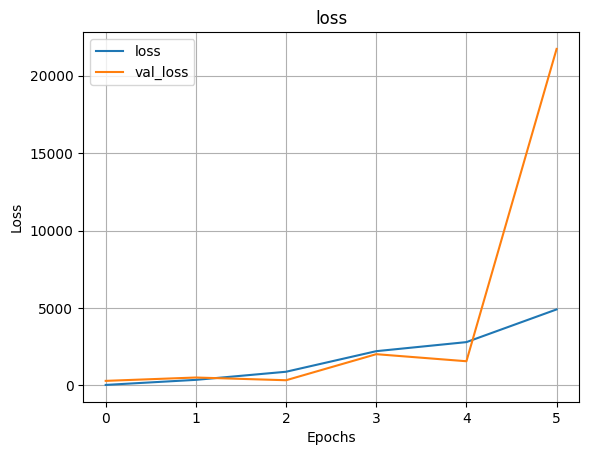

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step
                   precision    recall  f1-score   support

No Phishing Email       0.73      0.84      0.78     25308
   Phishing Email       0.83      0.71      0.77     27484

         accuracy                           0.77     52792
        macro avg       0.78      0.78      0.77     52792
     weighted avg       0.78      0.77      0.77     52792



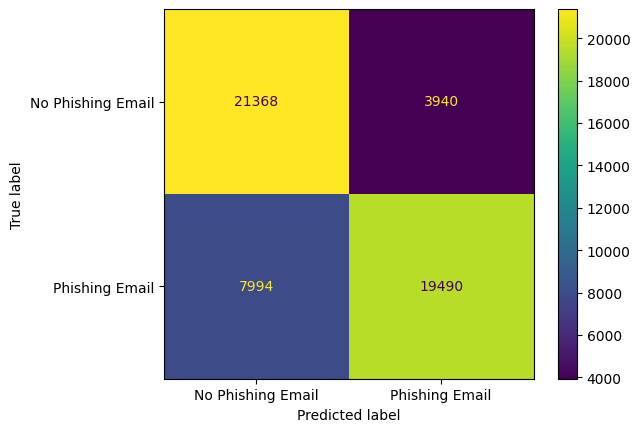

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step
                   precision    recall  f1-score   support

No Phishing Email       0.72      0.84      0.78      6301
   Phishing Email       0.83      0.71      0.76      6896

         accuracy                           0.77     13197
        macro avg       0.78      0.77      0.77     13197
     weighted avg       0.78      0.77      0.77     13197



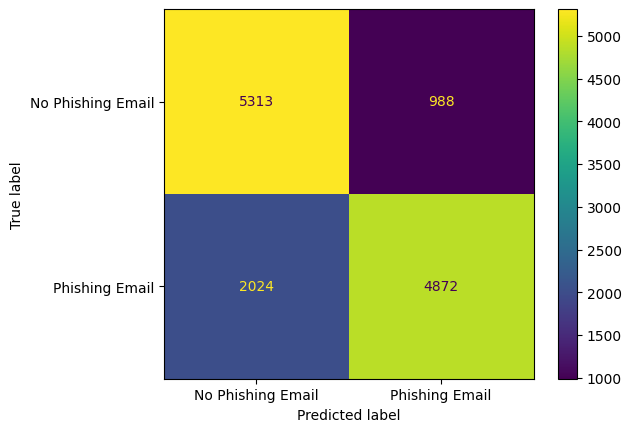


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=1
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8943 - loss: 51.4808 - val_accuracy: 0.8199 - val_loss: 384.2927
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9004 - loss: 723.1788 - val_accuracy: 0.9066 - val_loss: 850.2714
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=384.2927, stopped at epoch 2

Print History


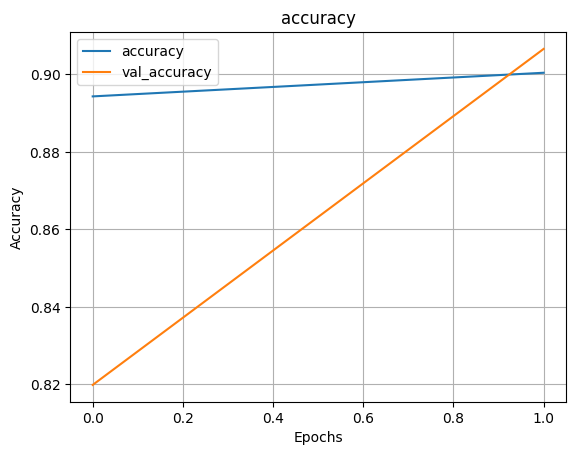

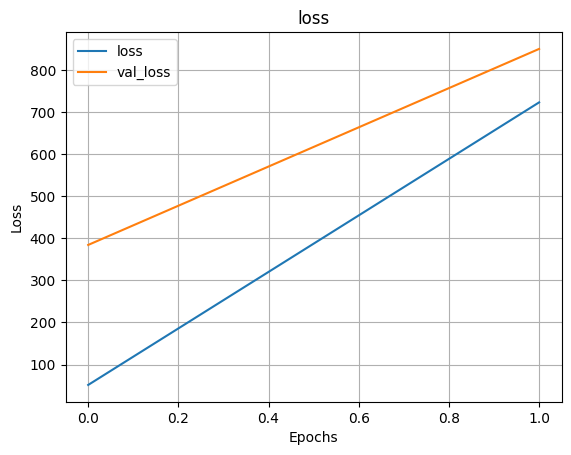

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step
                   precision    recall  f1-score   support

No Phishing Email       0.76      0.92      0.83     25308
   Phishing Email       0.91      0.74      0.81     27484

         accuracy                           0.82     52792
        macro avg       0.83      0.83      0.82     52792
     weighted avg       0.84      0.82      0.82     52792



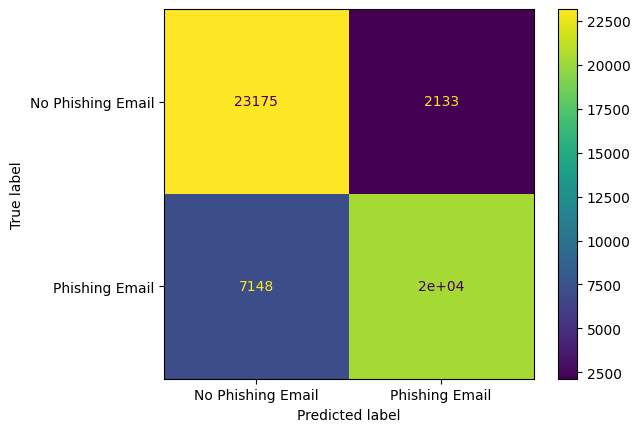

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step
                   precision    recall  f1-score   support

No Phishing Email       0.76      0.91      0.83      6301
   Phishing Email       0.90      0.74      0.81      6896

         accuracy                           0.82     13197
        macro avg       0.83      0.82      0.82     13197
     weighted avg       0.83      0.82      0.82     13197



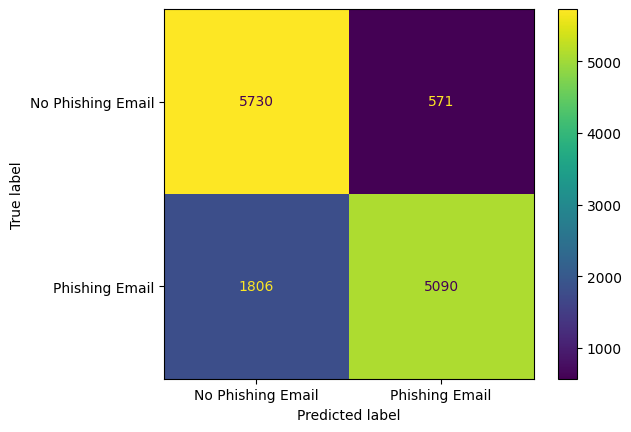


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=3
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.8958 - loss: 44.3421 - val_accuracy: 0.8585 - val_loss: 186.6054
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9036 - loss: 490.9127 - val_accuracy: 0.8948 - val_loss: 1001.5386
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9121 - loss: 1312.9615 - val_accuracy: 0.7972 - val_loss: 8980.5947
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9166 - loss: 2188.9495 - val_accuracy: 0.8295 - val_loss: 5382.1406
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=186.6054, stopped at epoch 4

Print History


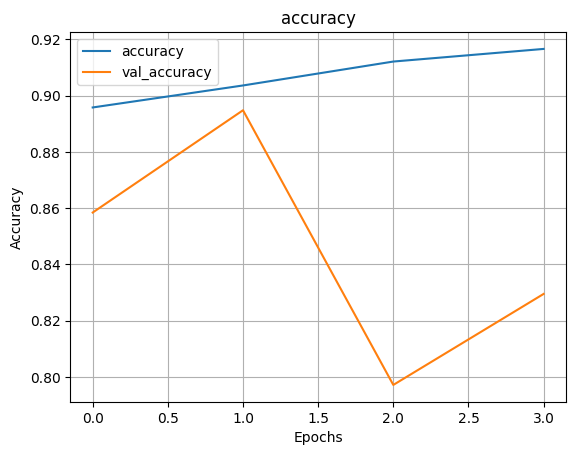

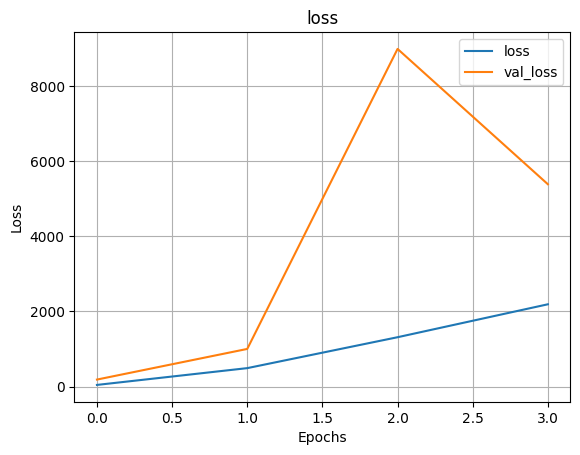

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step
                   precision    recall  f1-score   support

No Phishing Email       0.81      0.93      0.87     25308
   Phishing Email       0.93      0.80      0.86     27484

         accuracy                           0.86     52792
        macro avg       0.87      0.87      0.86     52792
     weighted avg       0.87      0.86      0.86     52792



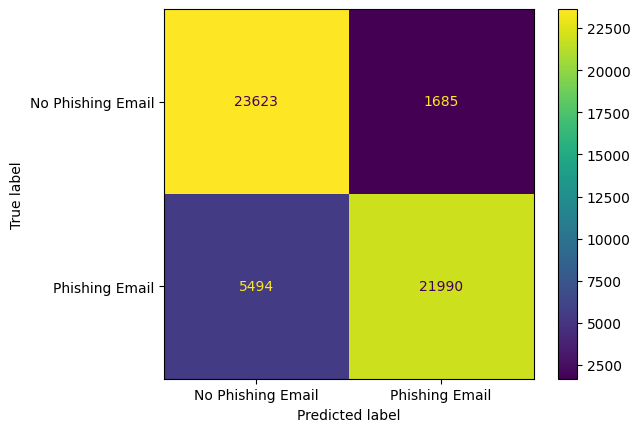

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
                   precision    recall  f1-score   support

No Phishing Email       0.81      0.93      0.86      6301
   Phishing Email       0.92      0.80      0.85      6896

         accuracy                           0.86     13197
        macro avg       0.86      0.86      0.86     13197
     weighted avg       0.87      0.86      0.86     13197



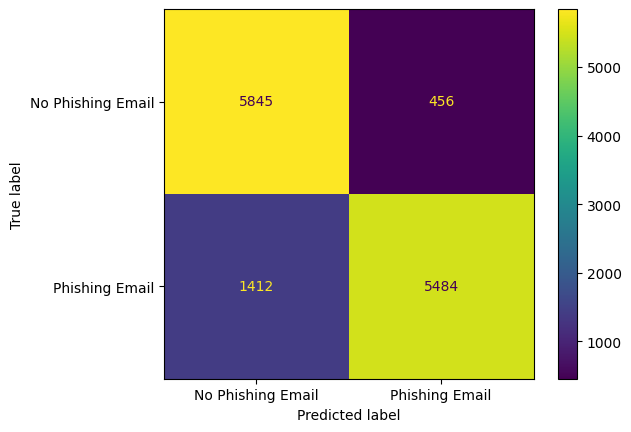


Config: layers=[256, 128, 64], epochs=50, min_delta=0.001, patience=5
Epoch 1/50


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8996 - loss: 26.7842 - val_accuracy: 0.9126 - val_loss: 77.0756
Epoch 2/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9111 - loss: 208.9183 - val_accuracy: 0.9476 - val_loss: 146.2778
Epoch 3/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9100 - loss: 719.8663 - val_accuracy: 0.8287 - val_loss: 1532.4075
Epoch 4/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9088 - loss: 1492.6257 - val_accuracy: 0.9413 - val_loss: 1182.5813
Epoch 5/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9084 - loss: 2857.5588 - val_accuracy: 0.9423 - val_loss: 1503.5151
Epoch 6/50
1650/1650 - 11s - 7ms/step - accuracy: 0.9162 - loss: 3932.0361 - val_accuracy: 0.9385 - val_loss: 2536.8254
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=77.0756, stopped at epoch 6

Print History


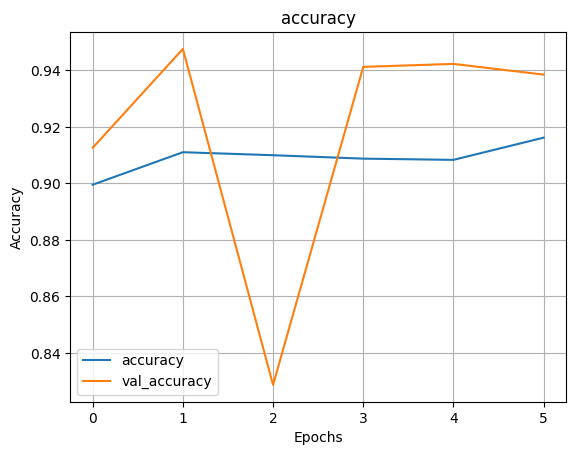

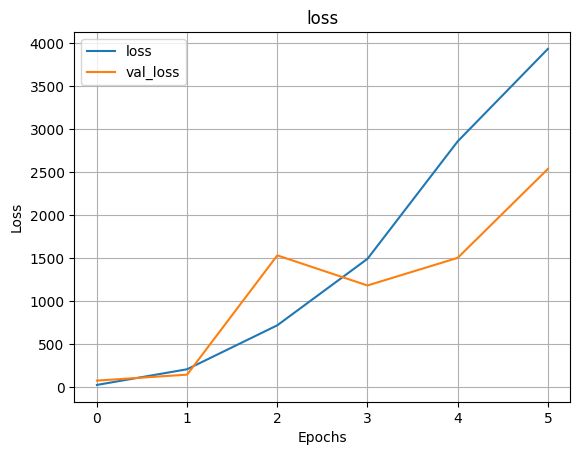

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step
                   precision    recall  f1-score   support

No Phishing Email       0.89      0.93      0.91     25308
   Phishing Email       0.93      0.90      0.92     27484

         accuracy                           0.91     52792
        macro avg       0.91      0.92      0.91     52792
     weighted avg       0.92      0.91      0.91     52792



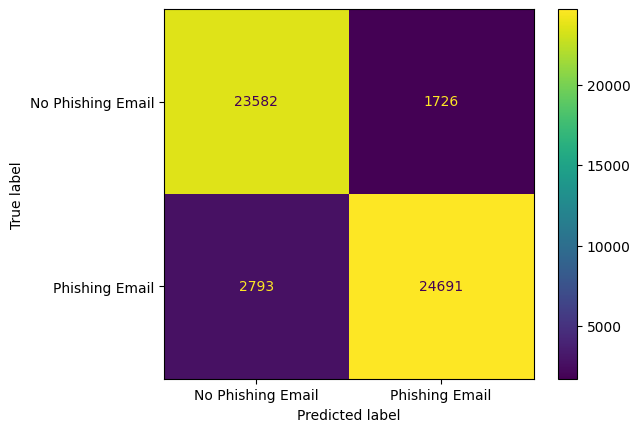

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step
                   precision    recall  f1-score   support

No Phishing Email       0.90      0.93      0.91      6301
   Phishing Email       0.93      0.90      0.92      6896

         accuracy                           0.91     13197
        macro avg       0.91      0.91      0.91     13197
     weighted avg       0.91      0.91      0.91     13197



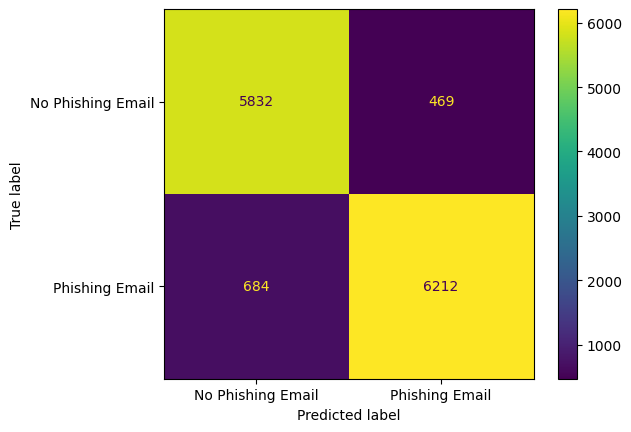


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8960 - loss: 29.5611 - val_accuracy: 0.9055 - val_loss: 52.7690
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.8959 - loss: 465.9219 - val_accuracy: 0.9458 - val_loss: 271.6396
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=52.7690, stopped at epoch 2

Print History


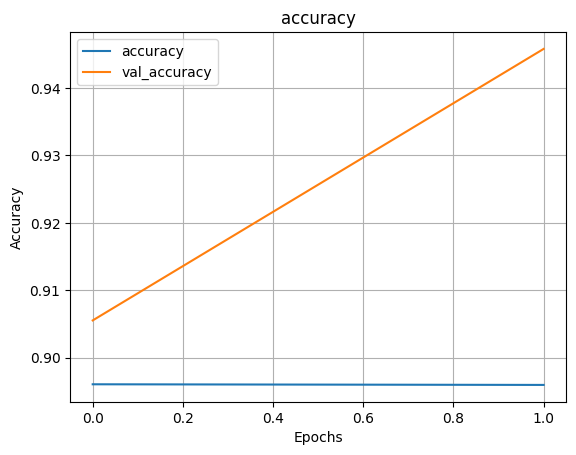

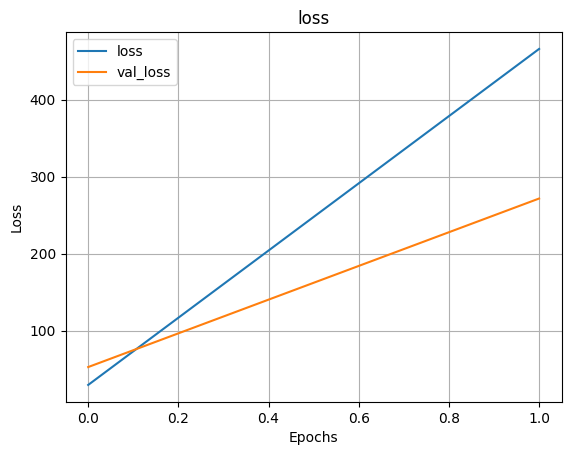

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step
                   precision    recall  f1-score   support

No Phishing Email       0.89      0.91      0.90     25308
   Phishing Email       0.92      0.89      0.90     27484

         accuracy                           0.90     52792
        macro avg       0.90      0.90      0.90     52792
     weighted avg       0.90      0.90      0.90     52792



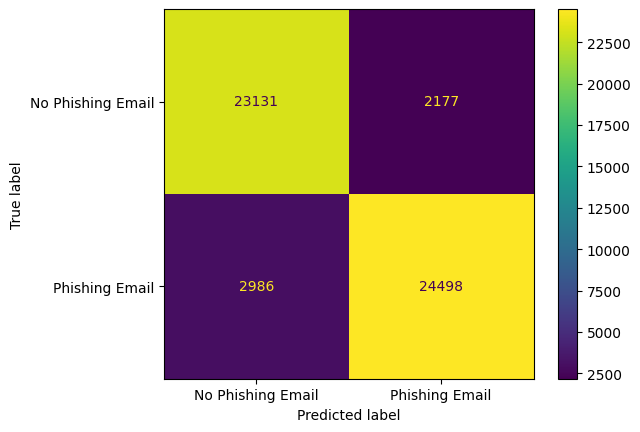

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step
                   precision    recall  f1-score   support

No Phishing Email       0.89      0.92      0.90      6301
   Phishing Email       0.92      0.89      0.91      6896

         accuracy                           0.91     13197
        macro avg       0.91      0.91      0.91     13197
     weighted avg       0.91      0.91      0.91     13197



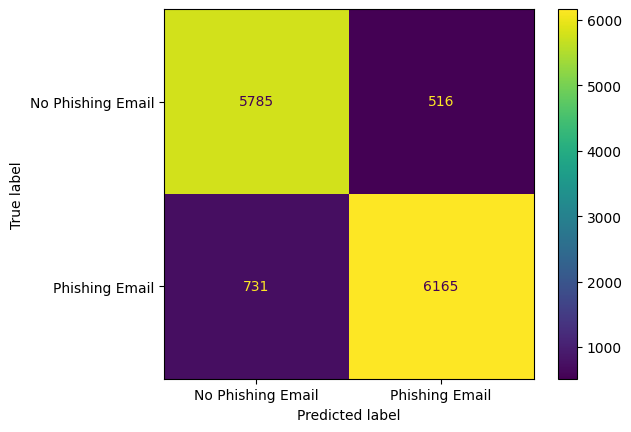


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.9035 - loss: 23.1891 - val_accuracy: 0.9517 - val_loss: 28.4007
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9121 - loss: 258.1234 - val_accuracy: 0.9410 - val_loss: 183.6396
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9152 - loss: 765.1782 - val_accuracy: 0.8678 - val_loss: 1834.0446
Epoch 4/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9236 - loss: 1013.5894 - val_accuracy: 0.7436 - val_loss: 5646.8130
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=28.4007, stopped at epoch 4

Print History


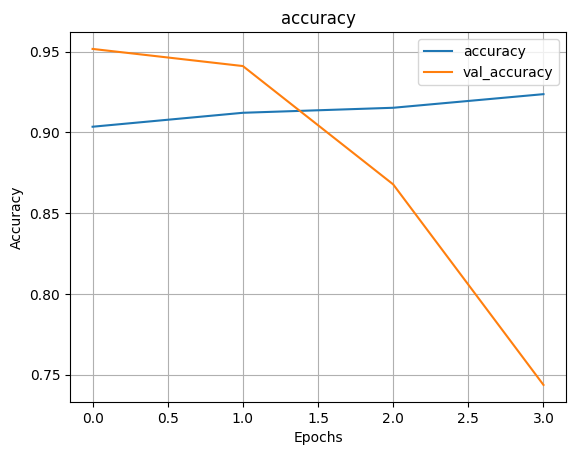

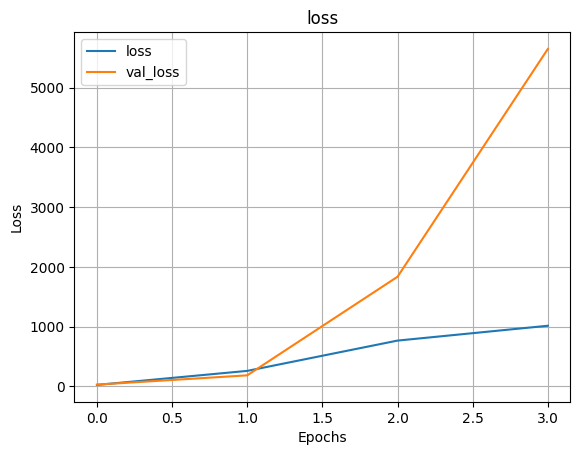

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 680us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.97      0.95     25308
   Phishing Email       0.97      0.93      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



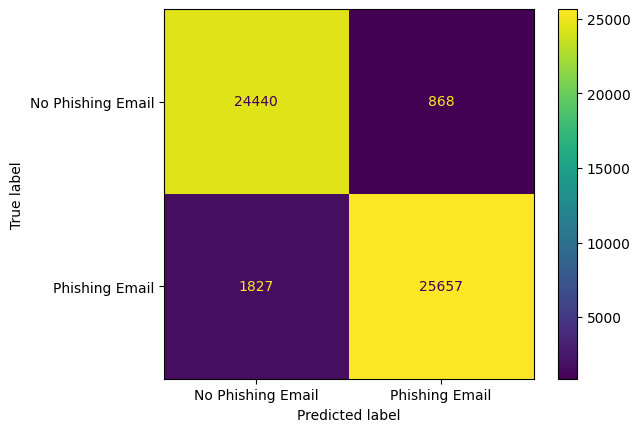

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step
                   precision    recall  f1-score   support

No Phishing Email       0.93      0.97      0.95      6301
   Phishing Email       0.97      0.94      0.95      6896

         accuracy                           0.95     13197
        macro avg       0.95      0.95      0.95     13197
     weighted avg       0.95      0.95      0.95     13197



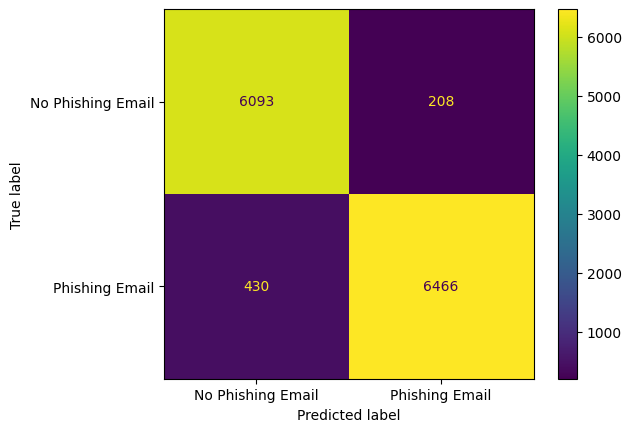


Config: layers=[256, 128, 64], epochs=100, min_delta=0.0, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.9059 - loss: 13.9438 - val_accuracy: 0.7015 - val_loss: 358.0646
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9097 - loss: 194.8487 - val_accuracy: 0.8373 - val_loss: 927.6285
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9177 - loss: 582.2752 - val_accuracy: 0.9367 - val_loss: 540.8817
Epoch 4/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9132 - loss: 1721.6729 - val_accuracy: 0.9536 - val_loss: 812.2395
Epoch 5/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9237 - loss: 2085.8005 - val_accuracy: 0.9345 - val_loss: 1747.6085
Epoch 6/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9143 - loss: 4243.5703 - val_accuracy: 0.9460 - val_loss: 2477.6604
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=358.0646, stopped at epoch 6

Print History


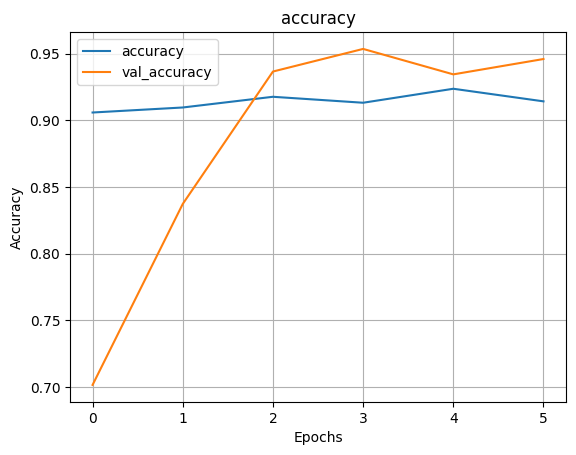

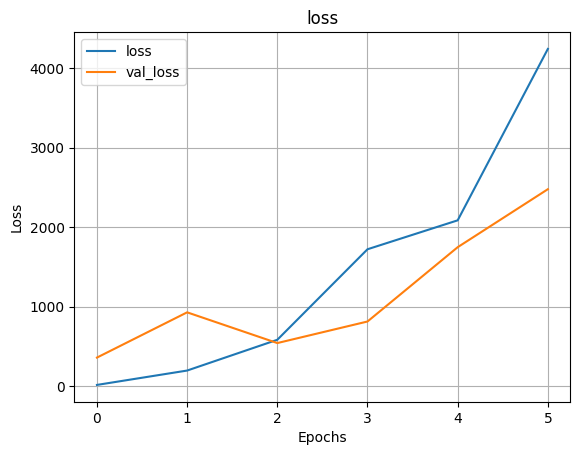

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step
                   precision    recall  f1-score   support

No Phishing Email       0.71      0.63      0.67     25308
   Phishing Email       0.69      0.77      0.73     27484

         accuracy                           0.70     52792
        macro avg       0.70      0.70      0.70     52792
     weighted avg       0.70      0.70      0.70     52792



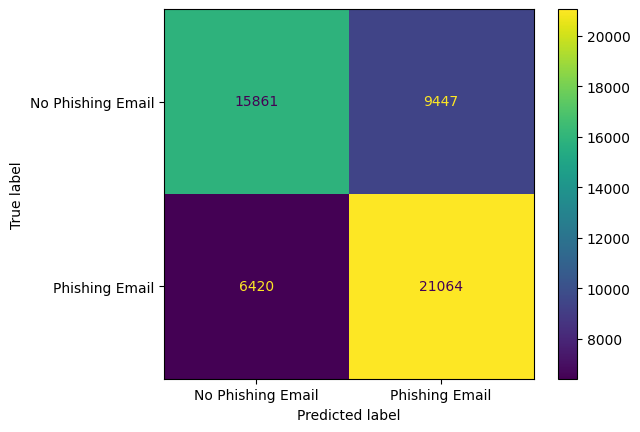

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step
                   precision    recall  f1-score   support

No Phishing Email       0.71      0.62      0.67      6301
   Phishing Email       0.69      0.77      0.73      6896

         accuracy                           0.70     13197
        macro avg       0.70      0.70      0.70     13197
     weighted avg       0.70      0.70      0.70     13197



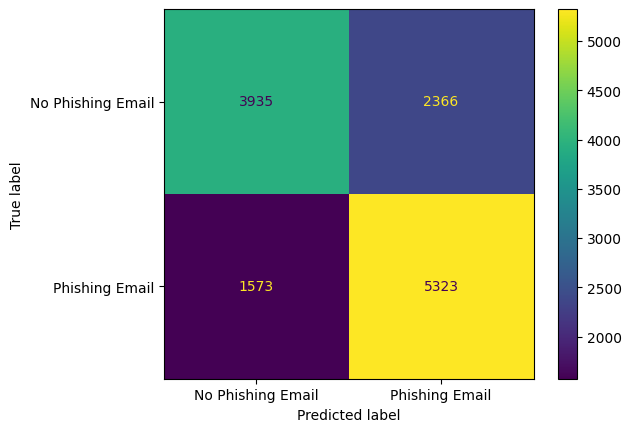


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=1
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8922 - loss: 51.8751 - val_accuracy: 0.7800 - val_loss: 460.2032
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.8932 - loss: 605.4763 - val_accuracy: 0.9270 - val_loss: 820.7226
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=460.2032, stopped at epoch 2

Print History


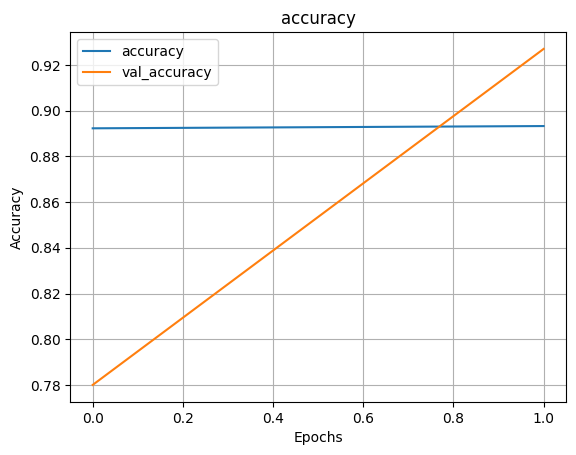

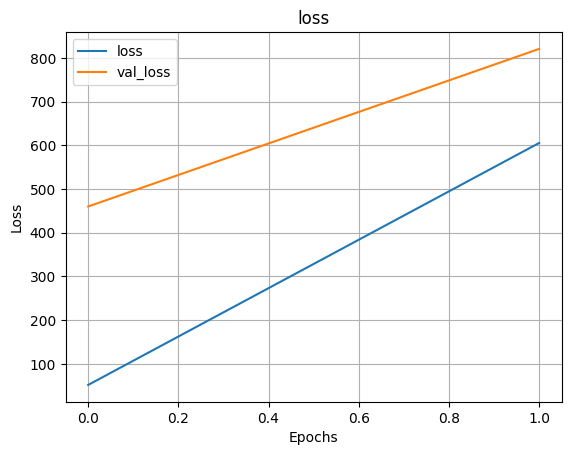

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step
                   precision    recall  f1-score   support

No Phishing Email       0.72      0.88      0.79     25308
   Phishing Email       0.86      0.68      0.76     27484

         accuracy                           0.78     52792
        macro avg       0.79      0.78      0.77     52792
     weighted avg       0.79      0.78      0.77     52792



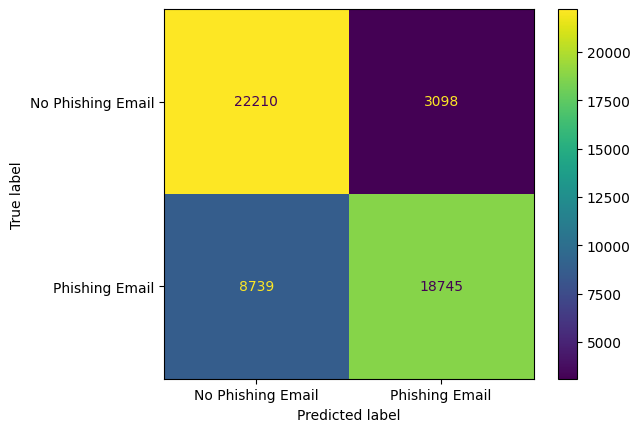

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
                   precision    recall  f1-score   support

No Phishing Email       0.72      0.88      0.79      6301
   Phishing Email       0.86      0.69      0.77      6896

         accuracy                           0.78     13197
        macro avg       0.79      0.78      0.78     13197
     weighted avg       0.79      0.78      0.78     13197



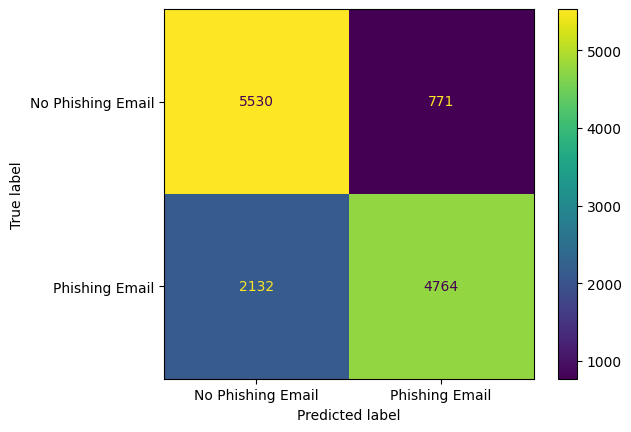


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=3
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 12s - 7ms/step - accuracy: 0.9030 - loss: 24.9462 - val_accuracy: 0.8579 - val_loss: 166.6134
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9092 - loss: 269.0899 - val_accuracy: 0.9190 - val_loss: 544.8237
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9179 - loss: 895.4341 - val_accuracy: 0.9485 - val_loss: 440.0987
Epoch 4/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9188 - loss: 1450.5548 - val_accuracy: 0.8762 - val_loss: 2593.5559
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=166.6134, stopped at epoch 4

Print History


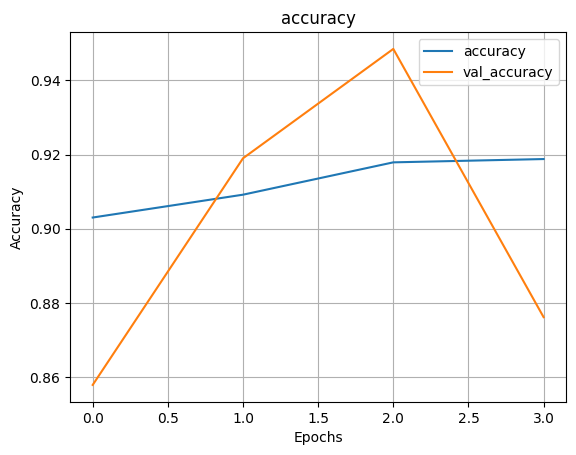

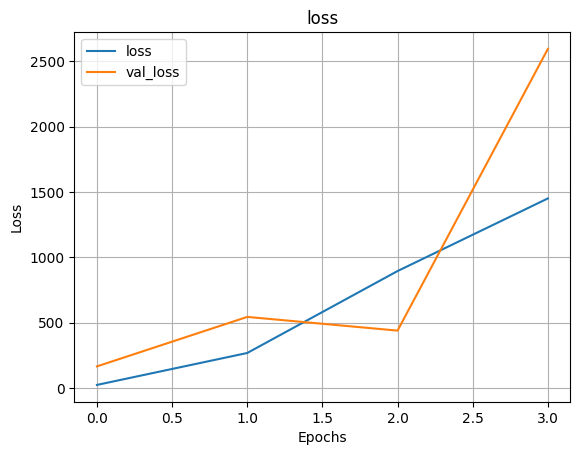

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step
                   precision    recall  f1-score   support

No Phishing Email       0.89      0.81      0.85     25308
   Phishing Email       0.84      0.91      0.87     27484

         accuracy                           0.86     52792
        macro avg       0.86      0.86      0.86     52792
     weighted avg       0.86      0.86      0.86     52792



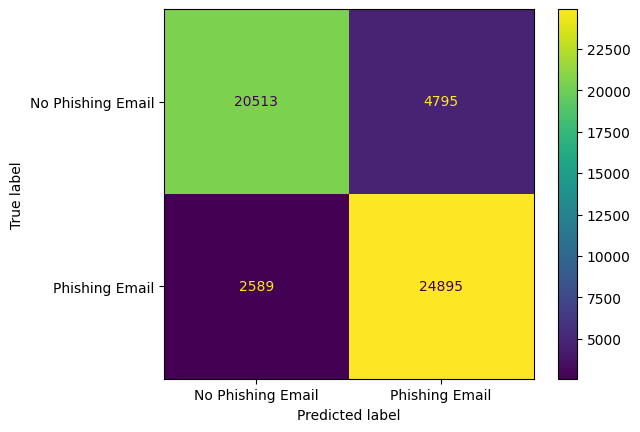

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step
                   precision    recall  f1-score   support

No Phishing Email       0.89      0.80      0.84      6301
   Phishing Email       0.83      0.91      0.87      6896

         accuracy                           0.86     13197
        macro avg       0.86      0.86      0.86     13197
     weighted avg       0.86      0.86      0.86     13197



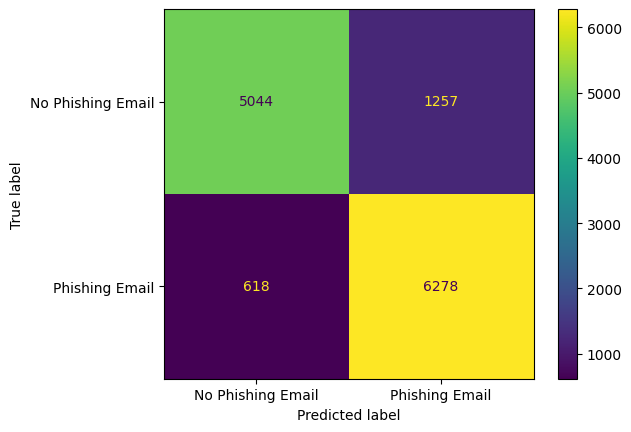


Config: layers=[256, 128, 64], epochs=100, min_delta=0.001, patience=5
Epoch 1/100


/Users/rod/MyApps/GitHub_Repos/CS_534_Intro_2_Artificial_Intelligence/group_project/Phase_2_Project_Proposal/mlp_model/.env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1650/1650 - 11s - 7ms/step - accuracy: 0.8973 - loss: 35.8135 - val_accuracy: 0.9445 - val_loss: 48.8371
Epoch 2/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9002 - loss: 359.8531 - val_accuracy: 0.9279 - val_loss: 481.0868
Epoch 3/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9058 - loss: 1109.0197 - val_accuracy: 0.9448 - val_loss: 705.4333
Epoch 4/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9093 - loss: 2056.2522 - val_accuracy: 0.9555 - val_loss: 870.3216
Epoch 5/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9141 - loss: 2888.8855 - val_accuracy: 0.9257 - val_loss: 2302.9595
Epoch 6/100
1650/1650 - 11s - 7ms/step - accuracy: 0.9055 - loss: 5539.1440 - val_accuracy: 0.9304 - val_loss: 4411.7397
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Finished. Best val_loss=48.8371, stopped at epoch 6

Print History


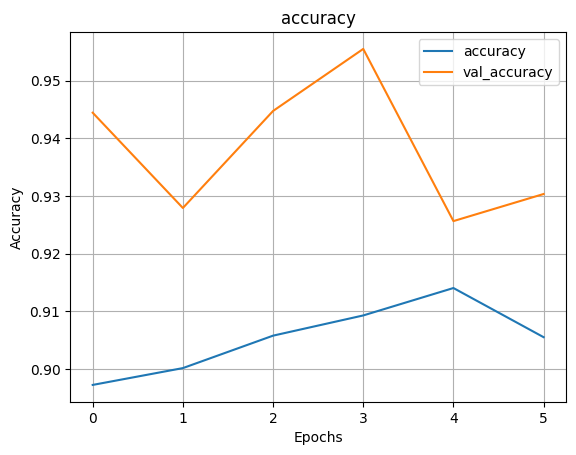

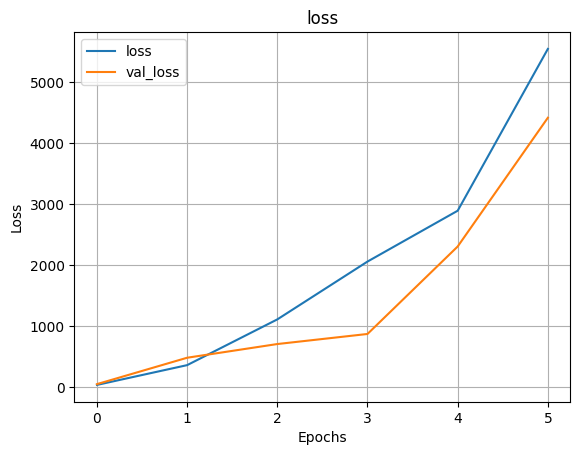

Training Evaluation:

1650/1650 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.94     25308
   Phishing Email       0.95      0.95      0.95     27484

         accuracy                           0.95     52792
        macro avg       0.95      0.95      0.95     52792
     weighted avg       0.95      0.95      0.95     52792



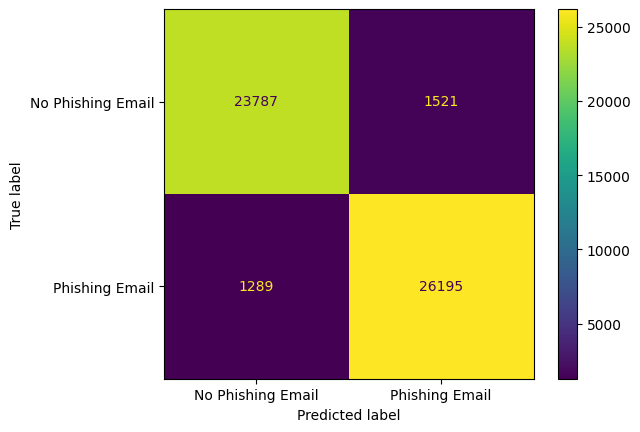

Validation Evaluation:

413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step
                   precision    recall  f1-score   support

No Phishing Email       0.95      0.94      0.94      6301
   Phishing Email       0.94      0.95      0.95      6896

         accuracy                           0.94     13197
        macro avg       0.94      0.94      0.94     13197
     weighted avg       0.94      0.94      0.94     13197



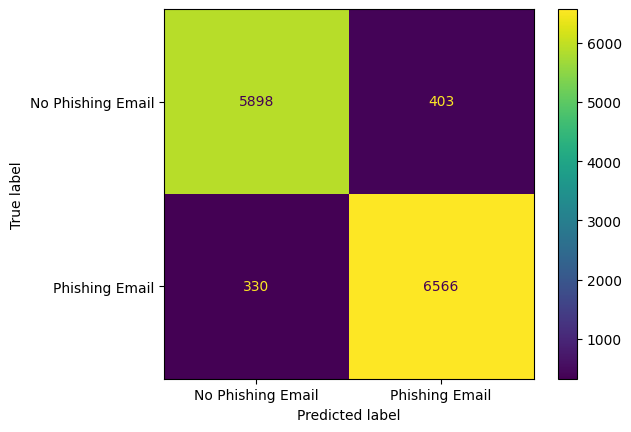

In [7]:
# Loop through all combinations of hyperparameters
for layers in layer_configs:
    for epochs in epochs_list:
        for min_delta in min_deltas:
            for patience in patiences:
                
                # Build the MLP model with specified layer configuration
                model = Sequential()
                
                # Add the input layer and the first hidden layer
                model.add(Dense(layers[0], activation='relu', input_shape=(X_train.shape[1],)))
                
                # Add any additional hidden layers
                for units in layers[1:]:
                    model.add(Dense(units, activation='relu'))
                
                # Add the output layer with sigmoid activation for binary classification
                model.add(Dense(1, activation='sigmoid'))

                # Compile the model with Adam optimizer and binary cross-entropy loss
                model.compile(optimizer=Adam(learning_rate=1e-3),
                              loss='binary_crossentropy',
                              metrics=['accuracy'])

                # Define EarlyStopping to stop training if val_loss doesn't improve
                early_stopping = EarlyStopping(
                    monitor='val_loss',       # Monitor validation loss
                    min_delta=min_delta,      # Minimum change to qualify as improvement
                    patience=patience,        # How many epochs to wait before stopping
                    restore_best_weights=True,# Restore weights from best epoch
                    verbose=1,
                    mode='min'                # Looking for minimum val_loss
                )

                # Define TimeStopping to stop training if it exceeds time limit
                time_stopping = TimeStopping(max_seconds=300)

                # Print current model configuration
                print(f"\nConfig: layers={layers}, epochs={epochs}, "
                      f"min_delta={min_delta}, patience={patience}")

                # Train the model with early stopping and time stopping callbacks
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    batch_size=32,
                    callbacks=[early_stopping, time_stopping],
                    verbose=2
                )

                # Capture the best validation loss achieved
                val_loss = min(history.history['val_loss'])
                print(f"Finished. Best val_loss={val_loss:.4f}, "
                      f"stopped at epoch {len(history.history['loss'])}\n")

                # Plot learning curves for loss and accuracy
                print("Print History")
                plot_history(history)
                
                # Evaluate on training set and print metrics
                print('Training Evaluation:\n')
                train_scores = eval_classification(model, X_train, y_train,
                                                   name=f'train {layers}-{epochs}-p{patience}-d{min_delta}',
                                                   labels=['No Phishing Email', 'Phishing Email'])

                # Evaluate on validation set and print metrics
                print('Validation Evaluation:\n')
                val_scores = eval_classification(model, X_val, y_val,
                                                 name=f'val {layers}-{epochs}-p{patience}-d{min_delta}',
                                                 labels=['No Phishing Email', 'Phishing Email'])

                # Combine train and validation scores for this run
                scores = pd.concat([train_scores, val_scores])
                all_scores.append(scores)

                # Track the best model based on validation F1 Score
                val_f1 = val_scores.iloc[0]['F1 Score']
                if val_f1 > best_f1:
                    best_f1 = val_f1
                    best_model = model
                    best_history = history
                    best_config = {
                        'layers': layers,
                        'epochs': epochs,
                        'min_delta': min_delta,
                        'patience': patience,
                        'val_f1_score': val_f1
                    }



🏆 Best Model Configuration:
layers: [64]
epochs: 100
min_delta: 0.001
patience: 3
val_f1_score: 0.9625938763720393

📁 Best model saved as 'best_mlp_model.h5'
Results saved to mlp_model_results.csv

📊 Training History of Best Model:


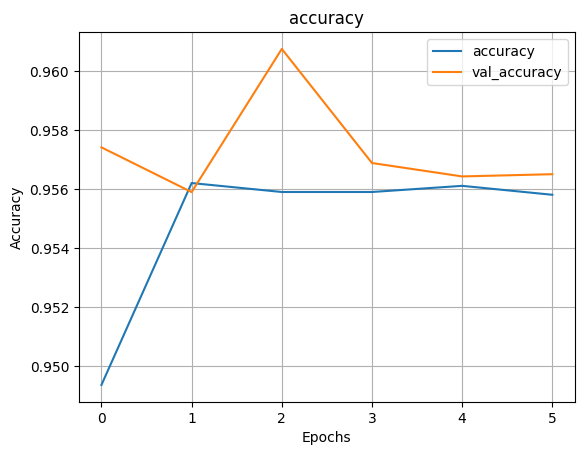

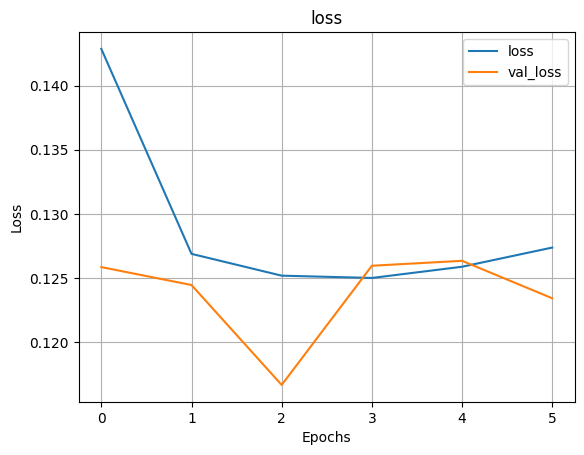

In [8]:
# Print best model config
print("\n🏆 Best Model Configuration:")
for k, v in best_config.items():
    print(f"{k}: {v}")

# Save best model
best_model.save('best_mlp_model.h5')
print("\n📁 Best model saved as 'best_mlp_model.h5'")

# Combine and save all scores
all_results_df = pd.concat(all_scores)
all_results_df.to_csv("mlp_model_results.csv", index=True)
print("Results saved to mlp_model_results.csv")

# Plot training history of the best model
print("\n📊 Training History of Best Model:")
plot_history(best_history)

In [9]:
# Filter only validation results
val_results = all_results_df[all_results_df.index.str.contains("val")]

# Sort by F1 Score in descending order
val_results_sorted = val_results.sort_values(by="F1 Score", ascending=False)

# Display the top results
print("🔝 Top Validation Results by F1 Score:")
display(val_results_sorted.head(10))

🔝 Top Validation Results by F1 Score:


,Accuracy,Precision,Recall,F1 Score,FPR,FNR
val [64]-100-p3-d0.001,0.960749,0.958717,0.966502,0.962594,0.045548,0.033498
val [64]-50-p3-d0.001,0.960218,0.956834,0.967517,0.962146,0.047770,0.032483
val [64]-100-p5-d0.0,0.960218,0.957621,0.966647,0.962113,0.046818,0.033353
val [64]-50-p5-d0.0,0.959688,0.958237,0.964907,0.961561,0.046024,0.035093
val [64]-50-p3-d0.0,0.959460,0.958351,0.964327,0.961330,0.045866,0.035673
val [64]-50-p1-d0.001,0.959385,0.958478,0.964037,0.961249,0.045707,0.035963
val [64]-50-p1-d0.0,0.958930,0.960435,0.960992,0.960713,0.043326,0.039008
val [64]-100-p5-d0.001,0.958627,0.956703,0.964472,0.960572,0.047770,0.035528
val [64]-50-p5-d0.001,0.958475,0.957349,0.963457,0.960393,0.046977,0.036543
val [64]-100-p1-d0.001,0.958400,0.956553,0.964182,0.960352,0.047929,0.035818
